
# **Predicción de diabetes a partir de indicadores de salud y estilo de vida**

## **1. Comprensión del Negocio**

**Contexto del problema**

La diabetes constituye un problema importante de salud pública. El dataset CDC Diabetes Health Indicators contiene información relacionada con condiciones de salud, hábitos de vida, acceso a servicios de salud y características sociodemográficas. A partir de estos datos se busca estudiar las características de la población y posteriormente desarrollar un modelo capaz de identificar personas con diabetes o prediabetes.

**¿En qué medida los indicadores de salud, estilo de vida y características sociodemográficas disponibles permiten caracterizar y posteriormente predecir la presencia de diabetes o prediabetes?**

**Objetivo general**

Desarrollar un modelo de clasificación basado en indicadores de salud, estilo de vida y características sociodemográficas que permita identificar la presencia de diabetes o prediabetes, siguiendo la metodología CRISP-DM.

## **2. Comprensión de los datos**

### **2.1 Carga de los datos**

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unir predictores y variable objetivo
df = pd.concat([X, y], axis=1)

print(f"Observaciones: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

df.head()

Observaciones: 253,680
Variables: 22


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


### **2.2 Clasificación de las variables**

In [4]:
target = "Diabetes_binary"

binary_cols = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

ordinal_cols = [
    "GenHlth",
    "Age",
    "Education",
    "Income"
]

numeric_cols = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]

In [5]:
print("Dimensiones:", df.shape)

display(
    pd.DataFrame({
        "Variable": df.columns,
        "Tipo pandas": df.dtypes.values,
        "Valores únicos": df.nunique().values
    })
)

Dimensiones: (253680, 22)


,Variable,Tipo pandas,Valores únicos
0,HighBP,int64,2
1,HighChol,int64,2
2,CholCheck,int64,2
3,BMI,int64,84
4,Smoker,int64,2
5,Stroke,int64,2
6,HeartDiseaseorAttack,int64,2
7,PhysActivity,int64,2
8,Fruits,int64,2
9,Veggies,int64,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

### **2.3 Calidad de los datos**

In [7]:
# Seleccionar únicamente variables numéricas
variables_numericas = df.select_dtypes(
    include=['int64', 'float64']
)

# Excluir la variable objetivo
variables_numericas = variables_numericas.drop(
    columns=['Diabetes_binary'],
    errors='ignore'
)

# Contar la proporción de valores iguales a 0
# en cada variable numérica
ceros_por_columna = (
    (variables_numericas == 0).sum()
    / len(df)
)

print("Proporción de valores iguales a 0 por variable:")
print(ceros_por_columna)

Proporción de valores iguales a 0 por variable:
HighBP                  0.570999
HighChol                0.575879
CholCheck               0.037330
BMI                     0.000000
Smoker                  0.556831
Stroke                  0.959429
HeartDiseaseorAttack    0.905814
PhysActivity            0.243456
Fruits                  0.365744
Veggies                 0.188580
HvyAlcoholConsump       0.943803
AnyHealthcare           0.048947
NoDocbcCost             0.915823
GenHlth                 0.000000
MentHlth                0.692526
PhysHlth                0.630921
DiffWalk                0.831776
Sex                     0.559658
Age                     0.000000
Education               0.000000
Income                  0.000000
dtype: float64


In [8]:
# Valores Faltantes
missing = pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Porcentaje": df.isna().mean() * 100
})

missing.sort_values("Nulos", ascending=False)

,Nulos,Porcentaje
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0
Veggies,0,0.0


In [9]:
# Valores unicos
unique_report = pd.DataFrame({
    "Variable": df.columns,
    "Valores_unicos": [df[col].nunique() for col in df.columns],
    "Minimo": [df[col].min() for col in df.columns],
    "Maximo": [df[col].max() for col in df.columns]
})

unique_report

,Variable,Valores_unicos,Minimo,Maximo
0,HighBP,2,0,1
1,HighChol,2,0,1
2,CholCheck,2,0,1
3,BMI,84,12,98
4,Smoker,2,0,1
5,Stroke,2,0,1
6,HeartDiseaseorAttack,2,0,1
7,PhysActivity,2,0,1
8,Fruits,2,0,1
9,Veggies,2,0,1


In [10]:
# Validación de variables binarias
for col in binary_cols + [target]:
    valores = sorted(df[col].unique())
    print(f"{col}: {valores}")

HighBP: [np.int64(0), np.int64(1)]
HighChol: [np.int64(0), np.int64(1)]
CholCheck: [np.int64(0), np.int64(1)]
Smoker: [np.int64(0), np.int64(1)]
Stroke: [np.int64(0), np.int64(1)]
HeartDiseaseorAttack: [np.int64(0), np.int64(1)]
PhysActivity: [np.int64(0), np.int64(1)]
Fruits: [np.int64(0), np.int64(1)]
Veggies: [np.int64(0), np.int64(1)]
HvyAlcoholConsump: [np.int64(0), np.int64(1)]
AnyHealthcare: [np.int64(0), np.int64(1)]
NoDocbcCost: [np.int64(0), np.int64(1)]
DiffWalk: [np.int64(0), np.int64(1)]
Sex: [np.int64(0), np.int64(1)]
Diabetes_binary: [np.int64(0), np.int64(1)]


In [11]:
# Resgitros Repetidos
duplicados = df.duplicated().sum()

print(f"Filas repetidas: {duplicados:,}")
print(f"Porcentaje: {duplicados / len(df) * 100:.2f}%")


# Eliminación de duplicados
df = df.drop_duplicates().reset_index(drop=True)

print(f"Filas después de eliminar duplicados: {len(df):,}")

Filas repetidas: 24,206
Porcentaje: 9.54%
Filas después de eliminar duplicados: 229,474


### **2.4 Análisis univariado**

In [12]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,229474.0,28.687507,6.789204,12.0,24.0,27.0,32.0,98.0
MentHlth,229474.0,3.509866,7.717643,0.0,0.0,0.0,2.0,30.0
PhysHlth,229474.0,4.681219,9.050877,0.0,0.0,0.0,4.0,30.0


In [13]:
numeric_summary = df[numeric_cols].describe().T

numeric_summary["mediana"] = df[numeric_cols].median()
numeric_summary["asimetria"] = df[numeric_cols].skew()

numeric_summary

,count,mean,std,min,25%,50%,75%,max,mediana,asimetria
BMI,229474.0,28.687507,6.789204,12.0,24.0,27.0,32.0,98.0,27.0,2.063475
MentHlth,229474.0,3.509866,7.717643,0.0,0.0,0.0,2.0,30.0,0.0,2.544532
PhysHlth,229474.0,4.681219,9.050877,0.0,0.0,0.0,4.0,30.0,0.0,2.044139


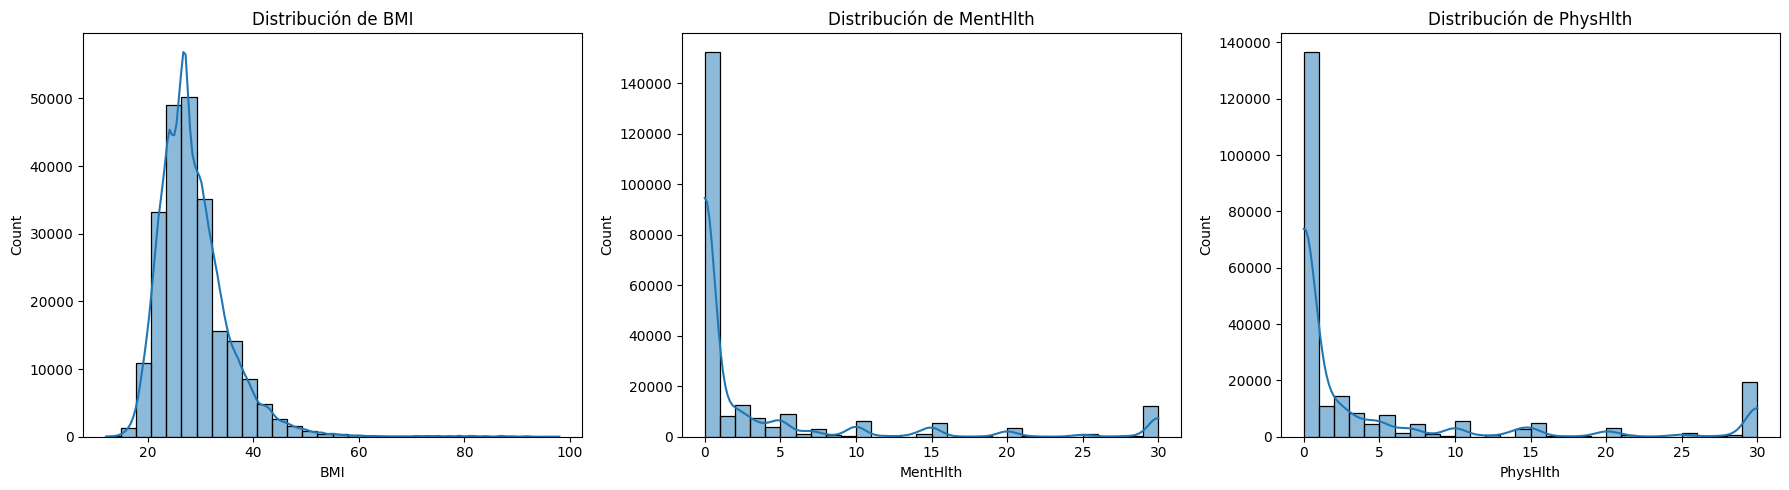

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

In [15]:
binary_summary = []

for col in binary_cols:
    counts = df[col].value_counts()

    binary_summary.append({
        "Variable": col,
        "0 (%)": (counts.get(0, 0) / len(df)) * 100,
        "1 (%)": (counts.get(1, 0) / len(df)) * 100
    })

binary_summary = pd.DataFrame(binary_summary)

binary_summary.round(2)

,Variable,0 (%),1 (%)
0,HighBP,54.57,45.43
1,HighChol,55.84,44.16
2,CholCheck,4.05,95.95
3,Smoker,53.42,46.58
4,Stroke,95.52,4.48
5,HeartDiseaseorAttack,89.67,10.33
6,PhysActivity,26.70,73.30
7,Fruits,38.73,61.27
8,Veggies,20.54,79.46
9,HvyAlcoholConsump,93.92,6.08


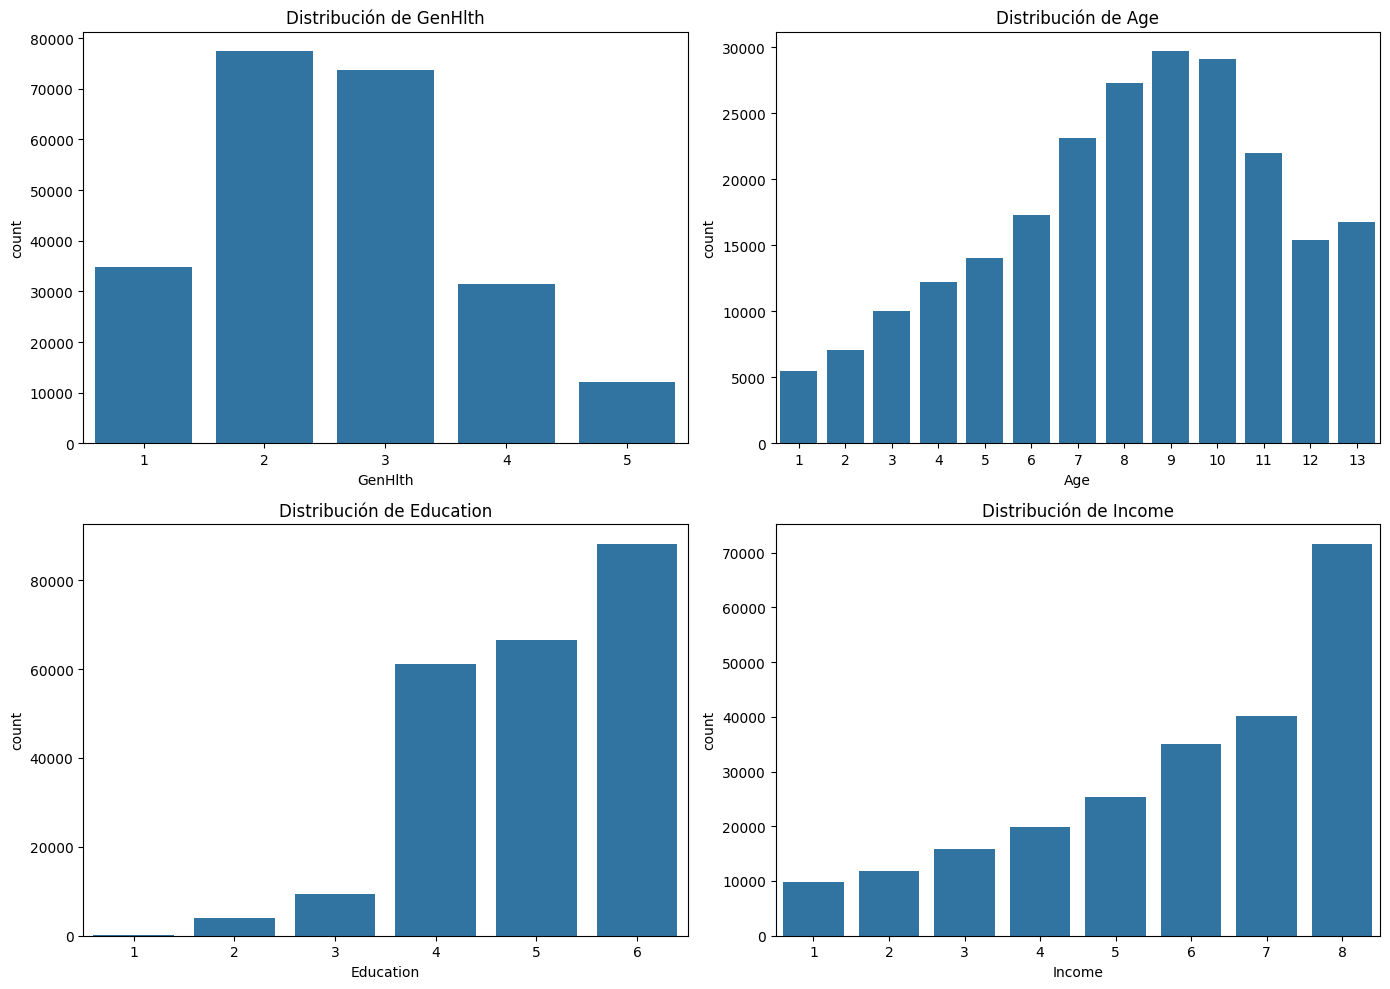

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ordinal_cols):
    sns.countplot(
        data=df,
        x=col,
        order=sorted(df[col].unique()),
        ax=ax
    )

    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

### **2.5 Variable Objetivo**

In [17]:
target_count = df[target].value_counts().sort_index()
target_pct = df[target].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Cantidad": target_count,
    "Porcentaje": target_pct
})

target_summary.index = [
    "Sin diabetes",
    "Prediabetes/Diabetes"
]

target_summary.round(2)

,Cantidad,Porcentaje
Sin diabetes,194377,84.71
Prediabetes/Diabetes,35097,15.29


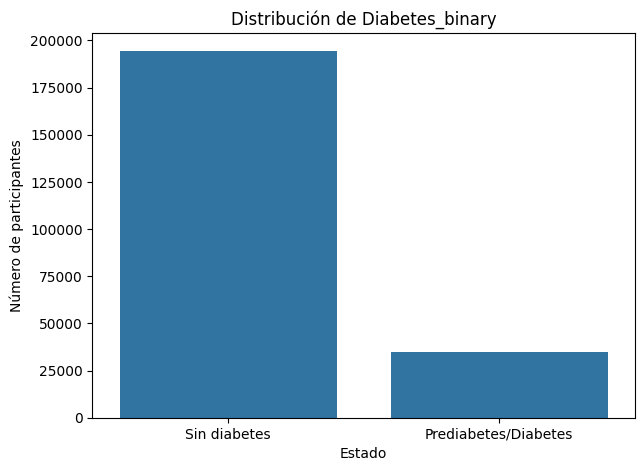

In [18]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=target
)

plt.title("Distribución de Diabetes_binary")
plt.xlabel("Estado")
plt.ylabel("Número de participantes")
plt.xticks(
    [0, 1],
    ["Sin diabetes", "Prediabetes/Diabetes"]
)

plt.show()

### **2.6 Analisis Bivariado**

#### **2.6.1 Binarias vs Diabetes**

In [19]:
binary_target_analysis = []

for col in binary_cols:

    rates = df.groupby(col)[target].mean() * 100

    binary_target_analysis.append({
        "Variable": col,
        "Diabetes cuando = 0 (%)": rates.get(0, np.nan),
        "Diabetes cuando = 1 (%)": rates.get(1, np.nan),
        "Diferencia (pp)": rates.get(1, np.nan) - rates.get(0, np.nan)
    })

binary_target_analysis = pd.DataFrame(binary_target_analysis)

binary_target_analysis.sort_values(
    "Diferencia (pp)",
    ascending=False
).round(2)

,Variable,Diabetes cuando = 0 (%),Diabetes cuando = 1 (%),Diferencia (pp)
5,HeartDiseaseorAttack,13.24,33.13,19.89
12,DiffWalk,11.77,30.77,19.00
0,HighBP,6.94,25.33,18.38
4,Stroke,14.52,31.78,17.26
1,HighChol,9.05,23.18,14.13
2,CholCheck,2.59,15.83,13.24
10,AnyHealthcare,11.48,15.51,4.03
3,Smoker,13.77,17.05,3.28
11,NoDocbcCost,15.06,17.55,2.49
13,Sex,14.25,16.63,2.37


#### **2.6.2 Ordinales vs Diabetes**

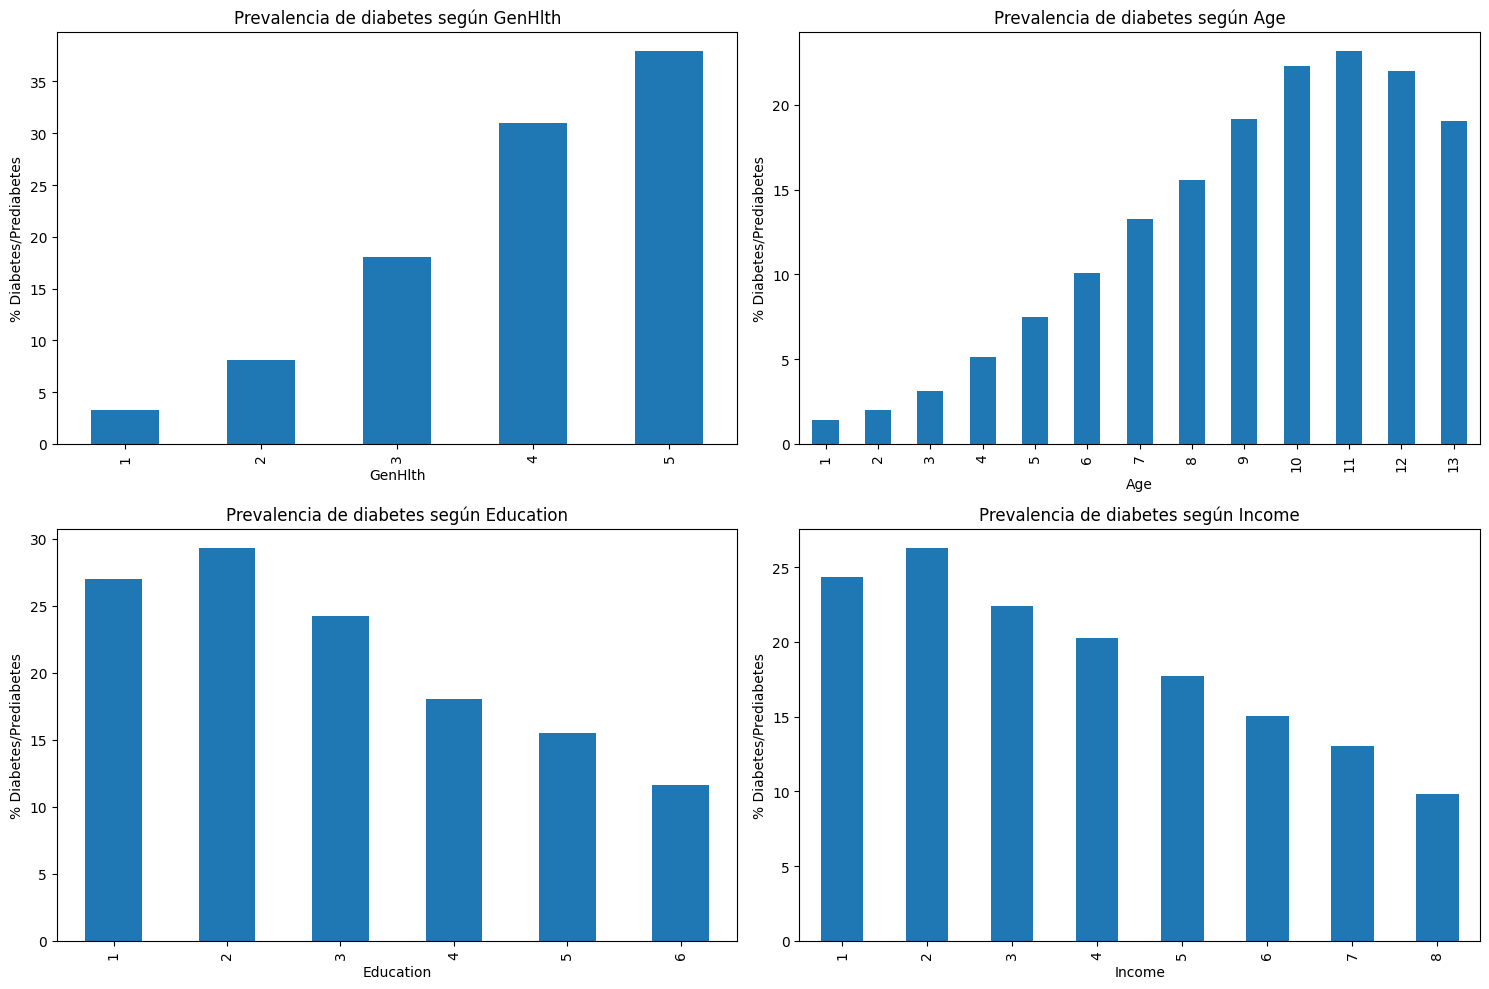

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, col in zip(axes.flatten(), ordinal_cols):

    prevalence = (
        df.groupby(col)[target]
        .mean()
        .mul(100)
    )

    prevalence.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Prevalencia de diabetes según {col}")
    ax.set_ylabel("% Diabetes/Prediabetes")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

#### **2.6.3 Numéricas vs Diabetes**

In [21]:
df.groupby(target)[numeric_cols].agg(
    ["mean", "median", "std"]
).T

Diabetes_binary          0          1
BMI      mean    28.095855  31.964242
         median  27.000000  31.000000
         std      6.503252   7.380385
MentHlth mean     3.332277   4.493404
         median   0.000000   0.000000
         std      7.455053   8.971501
PhysHlth mean     4.080442   8.008491
         median   0.000000   1.000000
         std      8.438609  11.320659

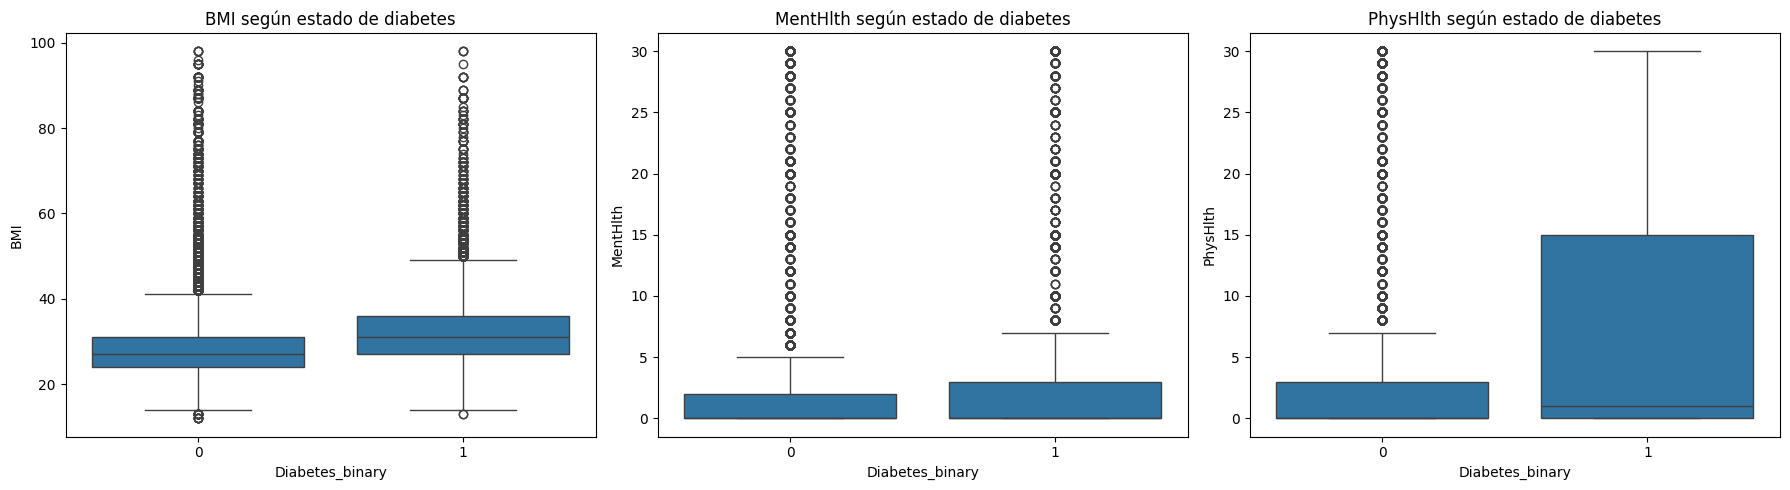

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):

    sns.boxplot(
        data=df,
        x=target,
        y=col,
        ax=ax
    )

    ax.set_title(f"{col} según estado de diabetes")
    ax.set_xlabel("Diabetes_binary")

plt.tight_layout()
plt.show()

### **2.7 Correlaciones**

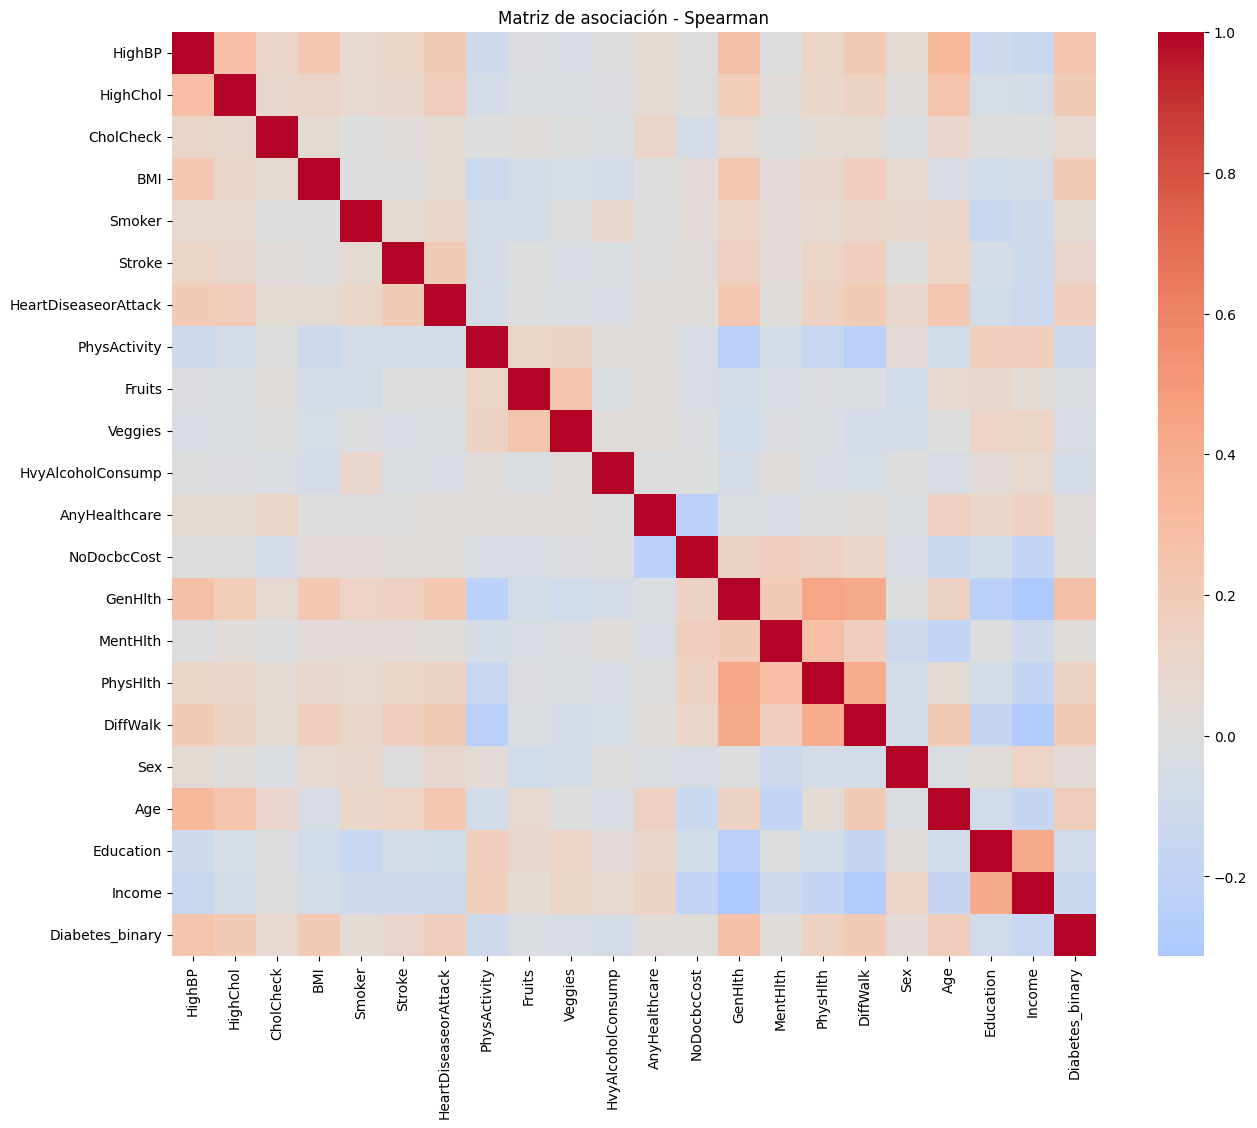

In [23]:
corr_spearman = df.corr(method="spearman")

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_spearman,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Matriz de asociación - Spearman")

plt.show()

In [24]:
target_corr = (
    corr_spearman[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_corr

,Diabetes_binary
GenHlth,0.273110
HighBP,0.254318
BMI,0.217964
DiffWalk,0.205302
HighChol,0.194944
Age,0.175375
HeartDiseaseorAttack,0.168213
Income,-0.138967
PhysHlth,0.137043
PhysActivity,-0.100404


In [25]:
target_corr = (
    corr_spearman[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_corr

,Diabetes_binary
GenHlth,0.273110
HighBP,0.254318
BMI,0.217964
DiffWalk,0.205302
HighChol,0.194944
Age,0.175375
HeartDiseaseorAttack,0.168213
Income,-0.138967
PhysHlth,0.137043
PhysActivity,-0.100404


### **2.8 Outliers**

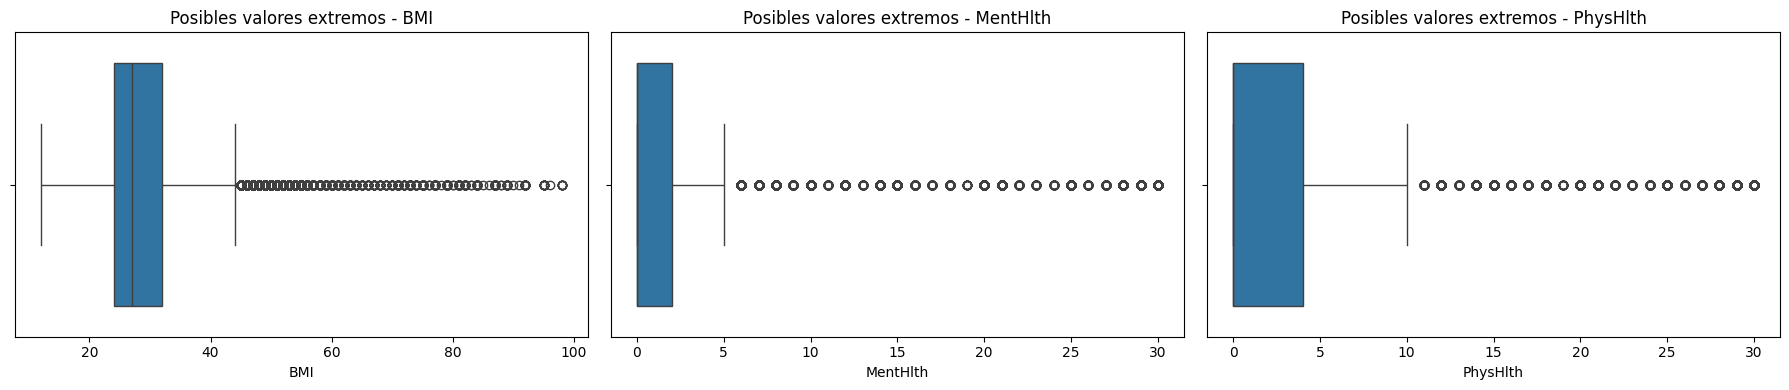

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, numeric_cols):

    sns.boxplot(
        x=df[col],
        ax=ax
    )

    ax.set_title(f"Posibles valores extremos - {col}")

plt.tight_layout()
plt.show()

In [27]:
outlier_report = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    outlier_report.append({
        "Variable": col,
        "Limite inferior": lower,
        "Limite superior": upper,
        "Posibles outliers": n_outliers,
        "%": n_outliers / len(df) * 100
    })

pd.DataFrame(outlier_report).round(2)

,Variable,Limite inferior,Limite superior,Posibles outliers,%
0,BMI,12.0,44.0,5638,2.46
1,MentHlth,-3.0,5.0,36162,15.76
2,PhysHlth,-6.0,10.0,34346,14.97


### **2.9 Hallazgos del EDA**

## **3. Preparación de los datos**

En esta fase se definen los conjuntos de variables que serán utilizados posteriormente durante el modelado y se realiza la división de los datos en conjuntos de entrenamiento y prueba.

A partir de los resultados obtenidos durante el análisis exploratorio se plantean dos escenarios: un conjunto completo con todas las variables predictoras disponibles y un conjunto reducido compuesto por las variables que mostraron una mayor asociación descriptiva con la variable objetivo

### **3.1 Selección preliminar de variables**

A partir del análisis exploratorio se identificó un grupo de variables que presentó una mayor asociación descriptiva con `Diabetes_binary`.

Las variables seleccionadas preliminarmente son:

* `GenHlth`
* `HighBP`
* `BMI`
* `DiffWalk`
* `HighChol`
* `Age`
* `HeartDiseaseorAttack`
* `Income`
* `PhysHlth`
* `Education`
* `PhysActivity`
* `Stroke`

Esta selección es **preliminar**. Una asociación individual baja con la variable objetivo no implica necesariamente que una característica carezca de capacidad predictiva cuando interactúa con otras variables.

Por esta razón, las variables restantes no se eliminan definitivamente. En la fase de modelado se comparará el desempeño obtenido utilizando todas las variables frente al subconjunto seleccionado.


In [28]:
# Variables seleccionadas a partir del EDA
selected_features = [
    "GenHlth",
    "HighBP",
    "BMI",
    "DiffWalk",
    "HighChol",
    "Age",
    "HeartDiseaseorAttack",
    "Income",
    "PhysHlth",
    "Education",
    "PhysActivity",
    "Stroke"
]

print(f"Número de variables seleccionadas: {len(selected_features)}")

selected_features

Número de variables seleccionadas: 12


['GenHlth',
 'HighBP',
 'BMI',
 'DiffWalk',
 'HighChol',
 'Age',
 'HeartDiseaseorAttack',
 'Income',
 'PhysHlth',
 'Education',
 'PhysActivity',
 'Stroke']

### **3.2 Definición de escenarios de variables**



Con el propósito de evaluar posteriormente si la reducción de variables afecta la capacidad predictiva, se construyen dos escenarios.

**Escenario A — Conjunto completo:** utiliza las 21 variables predictoras originales disponibles en el dataset.

**Escenario B — Conjunto reducido:** utiliza las 12 variables seleccionadas preliminarmente durante el análisis exploratorio.

Ambos escenarios conservarán la misma variable objetivo, `Diabetes_binary`.

Esta estrategia permitirá determinar posteriormente si un conjunto reducido de características puede alcanzar un desempeño comparable al obtenido utilizando toda la información disponible.


In [29]:
# Variable objetivo
target = "Diabetes_binary"

# Escenario A: todas las variables predictoras
X_full = df.drop(columns=[target]).copy()

# Escenario B: variables seleccionadas durante el EDA
X_selected = df[selected_features].copy()

# Variable objetivo
y = df[target].copy()

print("Escenario A - conjunto completo:", X_full.shape)
print("Escenario B - conjunto reducido:", X_selected.shape)
print("Variable objetivo:", y.shape)

Escenario A - conjunto completo: (229474, 21)
Escenario B - conjunto reducido: (229474, 12)
Variable objetivo: (229474,)


### **3.3 División de los datos en entrenamiento y prueba**

Para evaluar los modelos sobre observaciones que no hayan sido utilizadas durante su entrenamiento, el conjunto de datos se divide en:

* **80% para entrenamiento**
* **20% para prueba**

Debido al desbalance identificado previamente en `Diabetes_binary`, se utiliza una **partición estratificada** mediante `stratify=y`.

La estratificación permite conservar aproximadamente la misma proporción de personas sin diabetes y con diabetes/prediabetes tanto en el conjunto de entrenamiento como en el conjunto de prueba.

Además, ambos escenarios utilizarán exactamente las mismas observaciones para entrenamiento y evaluación. De esta manera, cualquier diferencia posterior en el desempeño podrá atribuirse principalmente al conjunto de variables utilizado y no a diferencias en las muestras.


In [30]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
# =========================
# ESCENARIO A
# 21 variables
# =========================

X_train_A = X_full.loc[train_idx]
X_test_A = X_full.loc[test_idx]


# =========================
# ESCENARIO B
# 12 variables
# =========================

X_train_B = X_selected.loc[train_idx]
X_test_B = X_selected.loc[test_idx]


# Target compartido por ambos escenarios
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

### **3.4 Verificación de la partición**

Se verifica el tamaño de los conjuntos generados y la distribución de la variable objetivo en entrenamiento y prueba para confirmar que la estratificación preservó el desbalance original de las clases.

In [32]:
print("ESCENARIO A")
print("Entrenamiento:", X_train_A.shape)
print("Prueba:", X_test_A.shape)

print("\nESCENARIO B")
print("Entrenamiento:", X_train_B.shape)
print("Prueba:", X_test_B.shape)

print("\nDistribución del target - Entrenamiento (%)")
print(
    (y_train.value_counts(normalize=True).sort_index() * 100).round(2)
)

print("\nDistribución del target - Prueba (%)")
print(
    (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
)

ESCENARIO A
Entrenamiento: (183579, 21)
Prueba: (45895, 21)

ESCENARIO B
Entrenamiento: (183579, 12)
Prueba: (45895, 12)

Distribución del target - Entrenamiento (%)
Diabetes_binary
0    84.71
1    15.29
Name: proportion, dtype: float64

Distribución del target - Prueba (%)
Diabetes_binary
0    84.71
1    15.29
Name: proportion, dtype: float64


## **4. Modelado**

En esta fase se entrenan modelos de clasificación utilizando los conjuntos de entrenamiento definidos previamente.

El objetivo es evaluar posteriormente tanto el efecto del algoritmo utilizado como el efecto de la selección de variables. Para ello se trabajará con los dos escenarios definidos durante la preparación de los datos:

* **Escenario A:** conjunto completo con 21 variables predictoras.
* **Escenario B:** conjunto reducido con 12 variables seleccionadas durante el análisis exploratorio.

Se utilizarán inicialmente dos algoritmos:

1. **Regresión Logística**, como modelo de referencia o *baseline*.
2. **Random Forest**, como modelo capaz de capturar relaciones no lineales e interacciones entre las variables.

Ambos algoritmos se entrenarán utilizando exactamente las mismas observaciones de entrenamiento. Debido al desbalance previamente identificado en la variable objetivo, se utilizará ponderación de clases mediante `class_weight="balanced"`.

En esta etapa se realiza únicamente el entrenamiento y generación de predicciones. La comparación formal mediante métricas se realizará posteriormente en la fase de **Evaluación**.


### **4.1 Regresión Logistica**

Se utiliza inicialmente una Regresión Logística como modelo de referencia debido a que el problema corresponde a una clasificación binaria.

Este modelo permite establecer un punto de comparación sencillo e interpretable antes de utilizar algoritmos de mayor complejidad.

Debido a que las variables presentan escalas diferentes, se utiliza StandardScaler dentro de un Pipeline para estandarizar los predictores antes del entrenamiento.

Además, se utiliza class_weight="balanced" para considerar el desbalance existente entre las clases.

La regresión logística será entrenada sobre los dos escenarios de variables definidos previamente.

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#### **4.1.1 Escenario A — 21 variable**


In [34]:
# Regresión Logística - Escenario A
logistic_A = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_A.fit(X_train_A, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

#### **4.1.2 Escenario B — 12 variables**


In [35]:
# Regresión Logística - Escenario B
logistic_B = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_B.fit(X_train_B, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

#### **4.1.3 Predicciones Regresión Logística**

In [36]:
# Escenario A
y_pred_log_A = logistic_A.predict(X_test_A)
y_prob_log_A = logistic_A.predict_proba(X_test_A)[:, 1]

# Escenario B
y_pred_log_B = logistic_B.predict(X_test_B)
y_prob_log_B = logistic_B.predict_proba(X_test_B)[:, 1]


### **4.2 Random Forest**

Como segundo algoritmo se utiliza Random Forest, un modelo basado en la combinación de múltiples árboles de decisión.

Este algoritmo resulta apropiado como alternativa a la Regresión Logística debido a que puede capturar relaciones no lineales e interacciones entre variables sin necesidad de especificarlas manualmente.

Además, Random Forest puede trabajar directamente con las variables utilizadas en este proyecto sin requerir estandarización previa.

Para mantener el tratamiento del desbalance de clases se utiliza nuevamente class_weight="balanced".

En esta primera iteración se utilizan los mismos hiperparámetros para ambos escenarios, de forma que la principal diferencia entre ellos sea el número de variables predictoras utilizadas. La optimización de hiperparámetros se realizará únicamente si los resultados de la evaluación justifican una nueva iteración del modelado.

In [37]:
from sklearn.ensemble import RandomForestClassifier

#### **4.2.1 Escenario A — 21 variables**


In [38]:
# Random Forest - Escenario A
rf_A = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_A.fit(X_train_A, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

#### **4.2.2 Escenario B — 12 variables**


In [39]:
# Random Forest - Escenario B
rf_B = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_B.fit(X_train_B, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

#### **4.2.3 Predicciones Random Forest**

In [40]:
# Escenario A
y_pred_rf_A = rf_A.predict(X_test_A)
y_prob_rf_A = rf_A.predict_proba(X_test_A)[:, 1]

# Escenario B
y_pred_rf_B = rf_B.predict(X_test_B)
y_prob_rf_B = rf_B.predict_proba(X_test_B)[:, 1]

## **5. Evaluación**

### **5.1 Métricas generales de desempeño**

In [41]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [42]:
def evaluar_modelo(nombre, y_true, y_pred, y_prob):

    return {
        "Modelo": nombre,

        # Métricas globales
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),

        # Clase 0 - Sin diabetes
        "Precision Clase 0": precision_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "Recall Clase 0": recall_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),
        "F1 Clase 0": f1_score(
            y_true, y_pred, pos_label=0, zero_division=0
        ),

        # Clase 1 - Diabetes / Prediabetes
        "Precision Clase 1": precision_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "Recall Clase 1": recall_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "F1 Clase 1": f1_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),

        # Promedios
        "F1 Macro": f1_score(
            y_true, y_pred, average="macro"
        ),
        "F1 Weighted": f1_score(
            y_true, y_pred, average="weighted"
        ),

        # Métricas basadas en probabilidades
        "ROC-AUC": roc_auc_score(
            y_true, y_prob
        ),

        "PR-AUC Clase 1": average_precision_score(
            y_true, y_prob
        )
    }

In [43]:
resultados_log_A = evaluar_modelo(
    "Logística A - 21 variables",
    y_test,
    y_pred_log_A,
    y_prob_log_A
)

resultados_log_B = evaluar_modelo(
    "Logística B - 12 variables",
    y_test,
    y_pred_log_B,
    y_prob_log_B
)

resultados_rf_A = evaluar_modelo(
    "Random Forest A - 21 variables",
    y_test,
    y_pred_rf_A,
    y_prob_rf_A
)

resultados_rf_B = evaluar_modelo(
    "Random Forest B - 12 variables",
    y_test,
    y_pred_rf_B,
    y_prob_rf_B
)

#### **5.1.1 Comparación general de métricas**

In [44]:
resultados = pd.DataFrame([
    resultados_log_A,
    resultados_log_B,
    resultados_rf_A,
    resultados_rf_B
])

resultados.set_index("Modelo").round(4)

,Accuracy,Balanced Accuracy,Precision Clase 0,Recall Clase 0,F1 Clase 0,Precision Clase 1,Recall Clase 1,F1 Clase 1,F1 Macro,F1 Weighted,ROC-AUC,PR-AUC Clase 1
Modelo,,,,,,,,,,,,
Logística A - 21 variables,0.7143,0.7331,0.9422,0.7060,0.8072,0.3183,0.7601,0.4487,0.6279,0.7524,0.8106,0.4121
Logística B - 12 variables,0.7143,0.7309,0.9411,0.7069,0.8074,0.3175,0.7550,0.4470,0.6272,0.7523,0.8060,0.4057
Random Forest A - 21 variables,0.8444,0.5593,0.8632,0.9701,0.9135,0.4726,0.1485,0.2259,0.5697,0.8084,0.7823,0.3587
Random Forest B - 12 variables,0.8151,0.5713,0.8676,0.9225,0.8942,0.3389,0.2201,0.2669,0.5805,0.7982,0.7407,0.2977


### **5.2 Desempeño por clase**

#### **5.2.1 Regresión Logística — Escenario A**

In [45]:
print(
    classification_report(
        y_test,
        y_pred_log_A,
        target_names=[
            "Sin diabetes",
            "Diabetes/Prediabetes"
        ]
    )
)

                      precision    recall  f1-score   support

        Sin diabetes       0.94      0.71      0.81     38876
Diabetes/Prediabetes       0.32      0.76      0.45      7019

            accuracy                           0.71     45895
           macro avg       0.63      0.73      0.63     45895
        weighted avg       0.85      0.71      0.75     45895



#### **5.2.2 Regresión Logística — Escenario B**

In [46]:
print(
    classification_report(
        y_test,
        y_pred_log_B,
        target_names=[
            "Sin diabetes",
            "Diabetes/Prediabetes"
        ]
    )
)

                      precision    recall  f1-score   support

        Sin diabetes       0.94      0.71      0.81     38876
Diabetes/Prediabetes       0.32      0.75      0.45      7019

            accuracy                           0.71     45895
           macro avg       0.63      0.73      0.63     45895
        weighted avg       0.85      0.71      0.75     45895



#### **5.2.3 Random Forest — Escenario A**

In [47]:
print(
    classification_report(
        y_test,
        y_pred_rf_A,
        target_names=[
            "Sin diabetes",
            "Diabetes/Prediabetes"
        ]
    )
)

                      precision    recall  f1-score   support

        Sin diabetes       0.86      0.97      0.91     38876
Diabetes/Prediabetes       0.47      0.15      0.23      7019

            accuracy                           0.84     45895
           macro avg       0.67      0.56      0.57     45895
        weighted avg       0.80      0.84      0.81     45895



#### **5.2.4 Random Forest — Escenario B**

In [48]:
print(
    classification_report(
        y_test,
        y_pred_rf_B,
        target_names=[
            "Sin diabetes",
            "Diabetes/Prediabetes"
        ]
    )
)

                      precision    recall  f1-score   support

        Sin diabetes       0.87      0.92      0.89     38876
Diabetes/Prediabetes       0.34      0.22      0.27      7019

            accuracy                           0.82     45895
           macro avg       0.60      0.57      0.58     45895
        weighted avg       0.79      0.82      0.80     45895



### **5.3 Matrices de confusión**

In [49]:
def mostrar_matriz(nombre, y_true, y_pred):

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=[
            "Sin diabetes",
            "Diabetes/Prediabetes"
        ],
        cmap="Blues"
    )

    plt.title(nombre)
    plt.show()

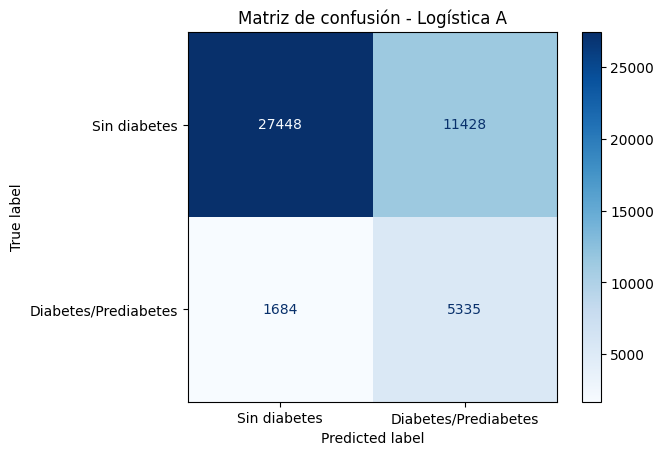

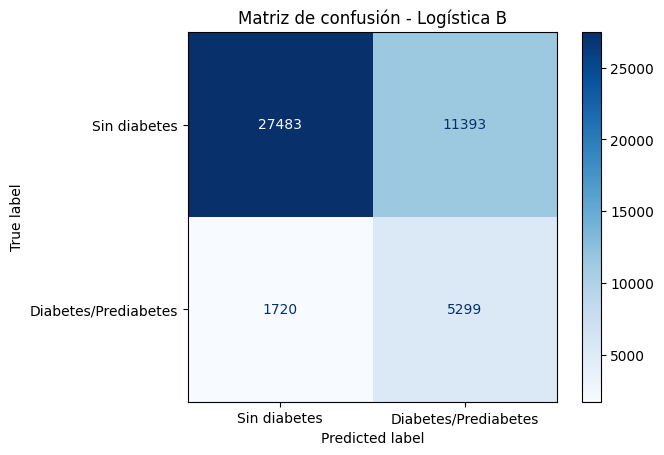

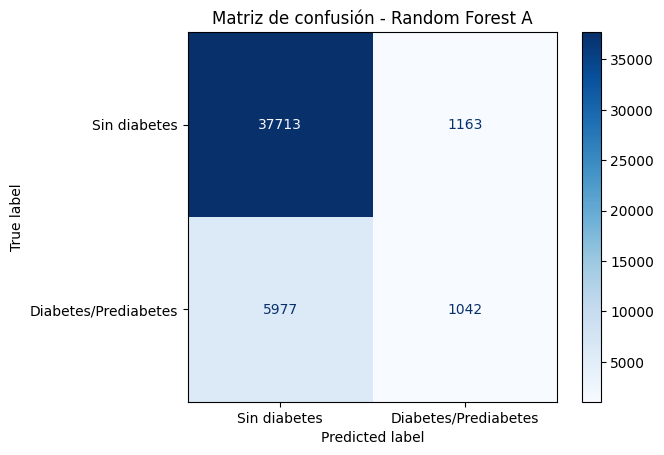

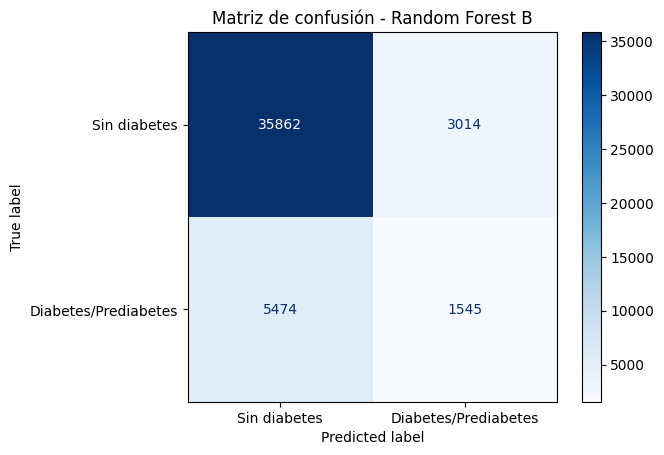

In [50]:
mostrar_matriz(
    "Matriz de confusión - Logística A",
    y_test,
    y_pred_log_A
)

mostrar_matriz(
    "Matriz de confusión - Logística B",
    y_test,
    y_pred_log_B
)

mostrar_matriz(
    "Matriz de confusión - Random Forest A",
    y_test,
    y_pred_rf_A
)

mostrar_matriz(
    "Matriz de confusión - Random Forest B",
    y_test,
    y_pred_rf_B
)

### **5.4 Curvas ROC**

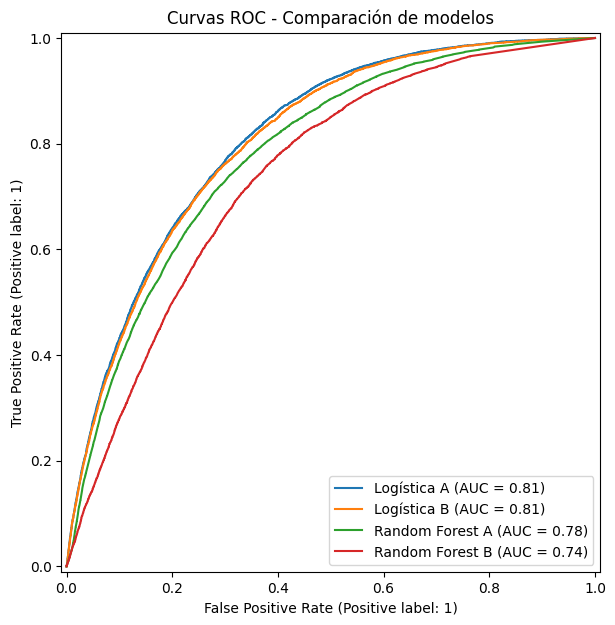

In [51]:
fig, ax = plt.subplots(figsize=(9, 7))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log_A,
    name="Logística A",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log_B,
    name="Logística B",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_A,
    name="Random Forest A",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_B,
    name="Random Forest B",
    ax=ax
)

plt.title("Curvas ROC - Comparación de modelos")
plt.show()

### **5.5 Curvas Precision-Recall**

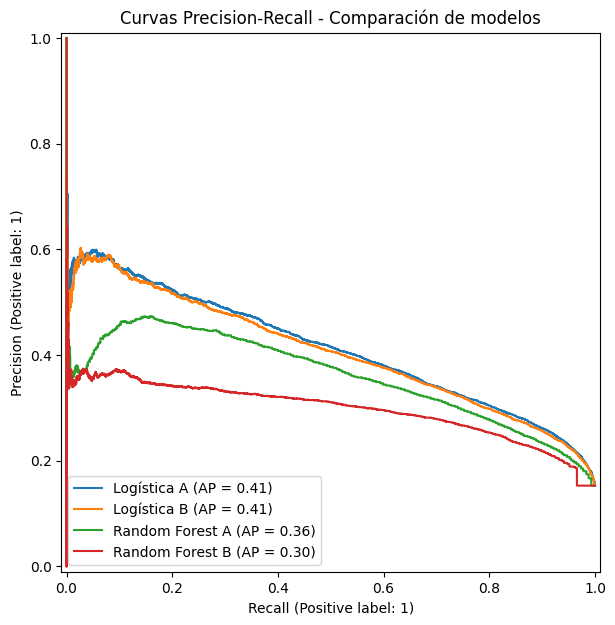

In [52]:
fig, ax = plt.subplots(figsize=(9, 7))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_log_A,
    name="Logística A",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_log_B,
    name="Logística B",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf_A,
    name="Random Forest A",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf_B,
    name="Random Forest B",
    ax=ax
)

plt.title("Curvas Precision-Recall - Comparación de modelos")
plt.show()

### **5.6 Selección del modelo candidato**

La evaluación inicial evidencia diferencias importantes entre los modelos analizados.

Aunque Random Forest presenta una mayor exactitud global, su desempeño está fuertemente influenciado por la clase mayoritaria. En particular, muestra una elevada capacidad para reconocer personas sin diabetes, pero una capacidad considerablemente menor para identificar la clase diabetes/prediabetes.

Las regresiones logísticas presentan un comportamiento más equilibrado entre ambas clases.

Entre ellas, la Regresión Logística del Escenario A, que utiliza las 21 variables disponibles, alcanza el mejor desempeño global en Balanced Accuracy, F1 Macro, ROC-AUC y PR-AUC.

Por esta razón, la Regresión Logística del Escenario A se selecciona como modelo candidato para una nueva iteración de optimización.

Las siguientes etapas utilizarán exclusivamente los datos de entrenamiento para seleccionar transformaciones, hiperparámetros y umbral de clasificación.

## **6. Optimización, comparación y selección del modelo final**

La evaluación inicial permitió seleccionar la Regresión Logística del Escenario A como el primer modelo candidato, debido a su comportamiento más equilibrado entre las dos clases frente a Random Forest.

A partir de este modelo se desarrolla una nueva iteración de optimización orientada a mejorar su capacidad predictiva mediante:

- tratamiento específico de las variables según su naturaleza;
- incorporación de relaciones no lineales para las variables numéricas;
- optimización de la regularización;
- optimización de la ponderación de clases;
- selección de un umbral de clasificación apropiado.

Debido al contexto del problema, se considera especialmente importante la capacidad de identificar observaciones pertenecientes a la clase **Diabetes/Prediabetes**.

Por esta razón, además de métricas globales, se presta especial atención al **Recall de la clase 1**, ya que una mayor sensibilidad permite reducir la cantidad de falsos negativos.

Posteriormente se incorpora **CatBoost** como modelo alternativo capaz de representar relaciones no lineales e interacciones entre variables de forma automática.

La selección entre los modelos candidatos se realizará utilizando exclusivamente información derivada del conjunto de entrenamiento mediante validación cruzada. El conjunto de prueba será reservado para la evaluación final del modelo seleccionado.

### **6.1 Preprocesamiento específico por tipo de variable**

El dataset contiene variables de diferente naturaleza.

Las variables binarias ya se encuentran codificadas mediante valores 0 y 1, por lo que se conservan sin transformación.

Las variables ordinales serán transformadas mediante `OneHotEncoder`, permitiendo que la Regresión Logística estime efectos diferentes para cada categoría sin asumir una relación estrictamente lineal entre categorías consecutivas.

Finalmente, para las variables numéricas se utilizarán funciones spline mediante `SplineTransformer`. Esta transformación permite representar relaciones no lineales entre variables como BMI, salud mental y salud física y la variable objetivo.

Posteriormente, las variables generadas mediante splines serán estandarizadas.

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    SplineTransformer
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [54]:
numeric_spline_v3 = Pipeline([
    (
        "spline",
        SplineTransformer(
            n_knots=5,
            degree=3,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [55]:
preprocessor_log_v3 = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_spline_v3,
            numeric_cols
        ),

        (
            "ordinal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            ordinal_cols
        ),

        (
            "binary",
            "passthrough",
            binary_cols
        )
    ]
)

### **6.2 Estrategia de validación**

Para comparar configuraciones del modelo se utiliza validación cruzada estratificada de cinco particiones.

La estratificación permite conservar la proporción de las clases en cada partición.

Debido al desbalance presente en la variable objetivo, la selección no se realizará únicamente mediante Accuracy. Se evaluarán métricas globales y métricas específicas de ambas clases.

Como criterio principal para la búsqueda de hiperparámetros se utilizará `F1 Macro`, ya que otorga el mismo peso a ambas clases.

In [56]:
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict
)

from sklearn.metrics import make_scorer

In [57]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [58]:
scoring_opt = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "roc_auc": "roc_auc",
    "pr_auc_1": "average_precision",

    "precision_0": make_scorer(
        precision_score,
        pos_label=0,
        zero_division=0
    ),

    "recall_0": make_scorer(
        recall_score,
        pos_label=0,
        zero_division=0
    ),

    "f1_0": make_scorer(
        f1_score,
        pos_label=0,
        zero_division=0
    ),

    "precision_1": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),

    "recall_1": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),

    "f1_1": make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    )
}

Para la búsqueda inicial de hiperparámetros de la Regresión Logística se utiliza `F1 Macro`, dado que permite evaluar de manera equilibrada ambas clases.

Sin embargo, para la selección posterior del **punto de operación o threshold**, se priorizará el **Recall de la clase Diabetes/Prediabetes**, manteniendo simultáneamente un Recall mínimo del 70% para la clase Sin diabetes.

Esta decisión permite orientar el modelo hacia la reducción de falsos negativos sin permitir que el reconocimiento de la clase negativa se deteriore excesivamente.

### **6.3 Construcción y optimización de la Regresión Logística V3**

La versión V3 conserva las 21 variables del Escenario A e incorpora el nuevo esquema de preprocesamiento.

Se optimizarán dos hiperparámetros principales:

`C`, que controla la intensidad de la regularización de la Regresión Logística, y `class_weight`, que determina la importancia relativa asignada a la clase diabetes/prediabetes.

La búsqueda se realiza mediante Grid Search y validación cruzada estratificada.

In [59]:
logistic_A_v3 = Pipeline([
    (
        "preprocessor",
        preprocessor_log_v3
    ),

    (
        "model",
        LogisticRegression(
            solver="lbfgs",
            max_iter=3000,
            random_state=42
        )
    )
])

In [60]:
param_grid_v3 = {
    "model__C": [
        0.01,
        0.05,
        0.10,
        0.50,
        1.00
    ],

    "model__class_weight": [
        {0: 1, 1: 2.0},
        {0: 1, 1: 2.5},
        {0: 1, 1: 3.0},
        "balanced"
    ]
}

In [61]:
grid_log_A_v3 = GridSearchCV(
    estimator=logistic_A_v3,
    param_grid=param_grid_v3,
    scoring=scoring_opt,
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_log_A_v3.fit(
    X_train_A,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('spline',
                                                                                          SplineTransformer(include_bias=False)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['BMI',
                                                                          'MentHlth',
                                                                          'PhysHlth']),
                                                                        ('ordinal',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['G...
                      'precision_0': make_scorer(precision_score, response_method='predict', pos_label=0, zero_division=0),
                      'precision_1': make_scorer(precision_score, response_method='predict', pos_label=1, zero_division=0),
                      'recall_0': make_scorer(recall_score, response_method='predict', pos_label=0, zero_division=0),
                      'recall_1': make_scorer(recall_score, response_method='predict', pos_label=1, zero_division=0),
                      'roc_auc': 'roc_auc'},
             verbose=1)

In [62]:
print("Mejores parámetros V3:")
print(grid_log_A_v3.best_params_)

print("\nF1 Macro promedio:")
print(
    round(
        grid_log_A_v3.best_score_,
        4
    )
)

Mejores parámetros V3:
{'model__C': 0.1, 'model__class_weight': {0: 1, 1: 2.5}}

F1 Macro promedio:
0.6747


### **6.4 Evaluación de la configuración seleccionada**

Una vez identificada la mejor configuración, se analizan las métricas obtenidas para ambas clases y las métricas globales.

Esto permite verificar que la selección del modelo no dependa únicamente de una única métrica.

In [63]:
best_idx_v3 = grid_log_A_v3.best_index_

metricas_v3_cv = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",

        "Precision Clase 0",
        "Recall Clase 0",
        "F1 Clase 0",

        "Precision Clase 1",
        "Recall Clase 1",
        "F1 Clase 1",

        "F1 Macro",
        "ROC-AUC",
        "PR-AUC Clase 1"
    ],

    "Media CV": [
        grid_log_A_v3.cv_results_[
            "mean_test_accuracy"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_balanced_accuracy"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_precision_0"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_recall_0"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_f1_0"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_precision_1"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_recall_1"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_f1_1"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_f1_macro"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_roc_auc"
        ][best_idx_v3],

        grid_log_A_v3.cv_results_[
            "mean_test_pr_auc_1"
        ][best_idx_v3]
    ]
})

metricas_v3_cv.round(4)

,Métrica,Media CV
0,Accuracy,0.8183
1,Balanced Accuracy,0.6891
2,Precision Clase 0,0.9070
3,Recall Clase 0,0.8753
4,F1 Clase 0,0.8909
5,Precision Clase 1,0.4214
6,Recall Clase 1,0.5028
7,F1 Clase 1,0.4585
8,F1 Macro,0.6747
9,ROC-AUC,0.8122


### **6.5 Optimización del umbral de V3 orientada a Recall**

La Regresión Logística genera un score continuo para la clase Diabetes/Prediabetes que posteriormente debe transformarse en una clasificación binaria.

Aunque el umbral estándar es 0.50, este valor no necesariamente representa el punto de operación más adecuado para el objetivo del proyecto.

En un contexto de identificación preliminar de perfiles asociados con diabetes/prediabetes, los falsos negativos adquieren especial relevancia. Un falso negativo corresponde a una observación realmente positiva que el modelo clasifica como Sin diabetes.

Por esta razón se redefine el criterio de selección del threshold para **priorizar el Recall de la clase 1**.

El criterio utilizado es:

- maximizar el Recall de la clase Diabetes/Prediabetes;
- mantener un Recall mínimo del 70% para la clase Sin diabetes;
- utilizar F2-score y Balanced Accuracy como métricas complementarias.

El F2-score se incorpora porque asigna mayor importancia al Recall que a la Precision.

Todas las decisiones sobre el threshold se realizan exclusivamente mediante predicciones out-of-fold generadas sobre el conjunto de entrenamiento mediante validación cruzada.

In [64]:
mejor_logistica_v3 = (
    grid_log_A_v3.best_estimator_
)

In [65]:
y_prob_cv_v3 = cross_val_predict(
    mejor_logistica_v3,
    X_train_A,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [66]:
from sklearn.metrics import fbeta_score

thresholds = np.round(
    np.arange(
        0.20,
        0.61,
        0.01
    ),
    2
)

resultados_threshold_v3 = []

for threshold in thresholds:

    y_pred_thr = (
        y_prob_cv_v3 >= threshold
    ).astype(int)

    resultados_threshold_v3.append({

        "Threshold": threshold,

        "Accuracy":
            accuracy_score(
                y_train,
                y_pred_thr
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_train,
                y_pred_thr
            ),

        "Precision Clase 0":
            precision_score(
                y_train,
                y_pred_thr,
                pos_label=0,
                zero_division=0
            ),

        "Recall Clase 0":
            recall_score(
                y_train,
                y_pred_thr,
                pos_label=0,
                zero_division=0
            ),

        "F1 Clase 0":
            f1_score(
                y_train,
                y_pred_thr,
                pos_label=0,
                zero_division=0
            ),

        "Precision Clase 1":
            precision_score(
                y_train,
                y_pred_thr,
                pos_label=1,
                zero_division=0
            ),

        "Recall Clase 1":
            recall_score(
                y_train,
                y_pred_thr,
                pos_label=1,
                zero_division=0
            ),

        "F1 Clase 1":
            f1_score(
                y_train,
                y_pred_thr,
                pos_label=1,
                zero_division=0
            ),

        "F2 Clase 1":
            fbeta_score(
                y_train,
                y_pred_thr,
                beta=2,
                pos_label=1,
                zero_division=0
            ),

        "F1 Macro":
            f1_score(
                y_train,
                y_pred_thr,
                average="macro"
            )
    })


threshold_v3_df = pd.DataFrame(
    resultados_threshold_v3
)

threshold_v3_df.round(4)

,Threshold,Accuracy,Balanced Accuracy,Precision Clase 0,Recall Clase 0,F1 Clase 0,Precision Clase 1,Recall Clase 1,F1 Clase 1,F2 Clase 1,F1 Macro
0,0.20,0.6061,0.7215,0.9648,0.5552,0.7048,0.2649,0.8879,0.4081,0.6039,0.5564
1,0.21,0.6183,0.7246,0.9628,0.5715,0.7172,0.2700,0.8778,0.4130,0.6053,0.5651
2,0.22,0.6300,0.7274,0.9609,0.5871,0.7289,0.2751,0.8677,0.4177,0.6064,0.5733
3,0.23,0.6416,0.7298,0.9589,0.6027,0.7402,0.2803,0.8570,0.4224,0.6071,0.5813
4,0.24,0.6524,0.7320,0.9571,0.6173,0.7505,0.2854,0.8466,0.4269,0.6077,0.5887
5,0.25,0.6630,0.7339,0.9552,0.6317,0.7605,0.2907,0.8360,0.4314,0.6080,0.5960
6,0.26,0.6725,0.7347,0.9531,0.6451,0.7694,0.2955,0.8243,0.4350,0.6070,0.6022
7,0.27,0.6818,0.7355,0.9511,0.6582,0.7780,0.3004,0.8128,0.4386,0.6060,0.6083
8,0.28,0.6912,0.7364,0.9493,0.6713,0.7865,0.3057,0.8014,0.4426,0.6051,0.6145
9,0.29,0.6999,0.7367,0.9474,0.6837,0.7942,0.3107,0.7898,0.4460,0.6037,0.6201


In [67]:
candidatos_recall_v3 = (
    threshold_v3_df[
        threshold_v3_df[
            "Recall Clase 0"
        ] >= 0.70
    ]
    .copy()
)

In [68]:
mejor_punto_recall_v3 = (
    candidatos_recall_v3
    .sort_values(
        by=[
            "Recall Clase 1",
            "F2 Clase 1",
            "Balanced Accuracy"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .iloc[0]
)

THRESHOLD_V3_RECALL = float(
    mejor_punto_recall_v3[
        "Threshold"
    ]
)

mejor_punto_recall_v3

,11
Threshold,0.310000
Accuracy,0.715676
Balanced Accuracy,0.735889
Precision Clase 0,0.943365
Recall Clase 0,0.706767
F1 Clase 0,0.808104
Precision Clase 1,0.320224
Recall Clase 1,0.765012
F1 Clase 1,0.451469
F2 Clase 1,0.598696


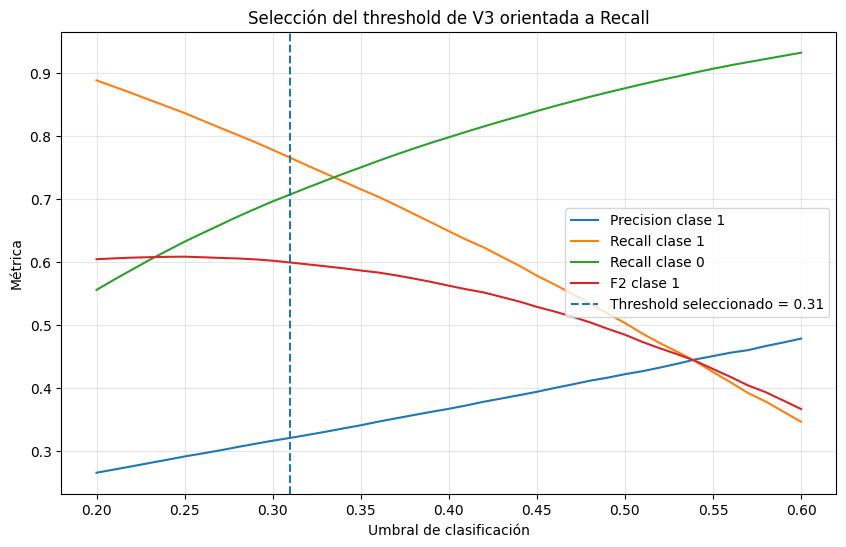

In [69]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_v3_df["Threshold"],
    threshold_v3_df["Precision Clase 1"],
    label="Precision clase 1"
)

plt.plot(
    threshold_v3_df["Threshold"],
    threshold_v3_df["Recall Clase 1"],
    label="Recall clase 1"
)

plt.plot(
    threshold_v3_df["Threshold"],
    threshold_v3_df["Recall Clase 0"],
    label="Recall clase 0"
)

plt.plot(
    threshold_v3_df["Threshold"],
    threshold_v3_df["F2 Clase 1"],
    label="F2 clase 1"
)

plt.axvline(
    x=THRESHOLD_V3_RECALL,
    linestyle="--",
    label=(
        f"Threshold seleccionado = "
        f"{THRESHOLD_V3_RECALL:.2f}"
    )
)

plt.xlabel(
    "Umbral de clasificación"
)

plt.ylabel(
    "Métrica"
)

plt.title(
    "Selección del threshold de V3 orientada a Recall"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

### **6.6 Resultado de V3 bajo el criterio orientado a Recall**

La modificación del criterio de selección del threshold cambia el punto de operación de la Regresión Logística V3.

En lugar de priorizar la Precision de la clase positiva, se busca ahora maximizar su Recall manteniendo un Recall mínimo del 70% para la clase Sin diabetes.

Mediante las predicciones out-of-fold del conjunto de entrenamiento se selecciona un threshold de aproximadamente **0.27**.

Con este punto de operación, V3 alcanza aproximadamente:

- Recall clase Diabetes/Prediabetes: 79.84%.
- Recall clase Sin diabetes: 70.40%.
- Precision clase Diabetes/Prediabetes: 30.39%.
- F2 clase Diabetes/Prediabetes: 60.24%.
- Balanced Accuracy: 75.12%.

La reducción del threshold incrementa la cantidad de observaciones clasificadas como positivas y, por lo tanto, permite reducir falsos negativos. Como consecuencia, también aumenta la cantidad de falsos positivos y disminuye la Precision de la clase positiva.

V3 se conserva como modelo candidato y será comparado posteriormente con CatBoost utilizando exactamente el mismo criterio de operación.

### **6.7 Evaluación de CatBoost como modelo alternativo**

Después de optimizar la Regresión Logística V3 se evalúa CatBoost como algoritmo alternativo.

CatBoost es un algoritmo de Gradient Boosting basado en árboles de decisión que permite representar automáticamente relaciones no lineales e interacciones entre variables.

En este proyecto se utilizan directamente como variables categóricas las variables binarias y ordinales, mientras que las variables numéricas se mantienen en su representación original.

Durante una exploración preliminar sobre una partición interna del conjunto de entrenamiento se evaluaron configuraciones de profundidad y learning rate.

Los resultados fueron muy similares entre las configuraciones analizadas. La configuración base obtuvo el mayor Recall de la clase positiva, mientras que el early stopping indicó un número óptimo cercano a 400 iteraciones.

Por esta razón se selecciona para la validación formal la siguiente configuración:

- `iterations = 400`
- `depth = 6`
- `learning_rate = 0.05`
- `l2_leaf_reg = 3`
- `auto_class_weights = "Balanced"`
- `loss_function = "Logloss"`

La configuración se evalúa mediante validación cruzada estratificada de cinco particiones y predicciones out-of-fold.

Al igual que para V3, el threshold se selecciona maximizando el Recall de la clase Diabetes/Prediabetes y manteniendo un Recall mínimo del 70% para la clase Sin diabetes.

In [70]:
!pip -q install catboost

from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00


In [71]:
X_train_catboost = (
    X_train_A
    .copy()
    .reset_index(drop=True)
)

y_train_catboost = (
    y_train
    .copy()
    .reset_index(drop=True)
)

cat_cols_catboost = (
    binary_cols
    + ordinal_cols
)

for col in cat_cols_catboost:

    X_train_catboost[col] = (
        X_train_catboost[col]
        .astype(str)
    )

print(
    "Observaciones:",
    X_train_catboost.shape[0]
)

print(
    "Variables predictoras:",
    X_train_catboost.shape[1]
)

print(
    "Variables categóricas:",
    len(cat_cols_catboost)
)

Observaciones: 183579
Variables predictoras: 21
Variables categóricas: 18


In [72]:
PARAMETROS_CATBOOST = {

    "iterations": 400,

    "depth": 6,

    "learning_rate": 0.05,

    "l2_leaf_reg": 3,

    "loss_function": "Logloss",

    "auto_class_weights": "Balanced",

    "random_seed": 42,

    "verbose": False,

    "allow_writing_files": False,

    "thread_count": -1
}

In [73]:
cv_catboost = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob_cv_catboost = np.zeros(
    len(y_train_catboost),
    dtype=float
)

print(
    "Validación cruzada CatBoost\n"
)

for fold, (
    idx_train,
    idx_val
) in enumerate(
    cv_catboost.split(
        X_train_catboost,
        y_train_catboost
    ),
    start=1
):

    print(
        f"Fold {fold}/5..."
    )

    X_fold_train = (
        X_train_catboost
        .iloc[idx_train]
    )

    X_fold_val = (
        X_train_catboost
        .iloc[idx_val]
    )

    y_fold_train = (
        y_train_catboost
        .iloc[idx_train]
    )

    modelo_fold_catboost = (
        CatBoostClassifier(
            **PARAMETROS_CATBOOST
        )
    )

    modelo_fold_catboost.fit(
        X_fold_train,
        y_fold_train,
        cat_features=cat_cols_catboost
    )

    y_prob_cv_catboost[
        idx_val
    ] = (
        modelo_fold_catboost
        .predict_proba(
            X_fold_val
        )[:, 1]
    )

print(
    "\nValidación cruzada terminada."
)

Validación cruzada CatBoost

Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...

Validación cruzada terminada.


In [74]:
roc_auc_cv_catboost = roc_auc_score(
    y_train_catboost,
    y_prob_cv_catboost
)

pr_auc_cv_catboost = (
    average_precision_score(
        y_train_catboost,
        y_prob_cv_catboost
    )
)


thresholds_catboost = np.round(
    np.arange(
        0.20,
        0.71,
        0.01
    ),
    2
)

resultados_threshold_catboost = []

for threshold in thresholds_catboost:

    y_pred_thr = (
        y_prob_cv_catboost
        >= threshold
    ).astype(int)

    resultados_threshold_catboost.append({

        "Threshold":
            threshold,

        "Accuracy":
            accuracy_score(
                y_train_catboost,
                y_pred_thr
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_train_catboost,
                y_pred_thr
            ),

        "Precision Clase 0":
            precision_score(
                y_train_catboost,
                y_pred_thr,
                pos_label=0,
                zero_division=0
            ),

        "Recall Clase 0":
            recall_score(
                y_train_catboost,
                y_pred_thr,
                pos_label=0,
                zero_division=0
            ),

        "F1 Clase 0":
            f1_score(
                y_train_catboost,
                y_pred_thr,
                pos_label=0,
                zero_division=0
            ),

        "Precision Clase 1":
            precision_score(
                y_train_catboost,
                y_pred_thr,
                pos_label=1,
                zero_division=0
            ),

        "Recall Clase 1":
            recall_score(
                y_train_catboost,
                y_pred_thr,
                pos_label=1,
                zero_division=0
            ),

        "F1 Clase 1":
            f1_score(
                y_train_catboost,
                y_pred_thr,
                pos_label=1,
                zero_division=0
            ),

        "F2 Clase 1":
            fbeta_score(
                y_train_catboost,
                y_pred_thr,
                beta=2,
                pos_label=1,
                zero_division=0
            ),

        "F1 Macro":
            f1_score(
                y_train_catboost,
                y_pred_thr,
                average="macro"
            ),

        "F1 Weighted":
            f1_score(
                y_train_catboost,
                y_pred_thr,
                average="weighted"
            )
    })


threshold_catboost_df = pd.DataFrame(
    resultados_threshold_catboost
)

In [75]:
candidatos_catboost = (
    threshold_catboost_df[
        threshold_catboost_df[
            "Recall Clase 0"
        ] >= 0.70
    ]
    .copy()
)


mejor_punto_catboost = (
    candidatos_catboost
    .sort_values(
        by=[
            "Recall Clase 1",
            "F2 Clase 1",
            "Balanced Accuracy"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .iloc[0]
)


THRESHOLD_CATBOOST = float(
    mejor_punto_catboost[
        "Threshold"
    ]
)


resultado_cv_catboost = (
    mejor_punto_catboost
    .to_dict()
)

resultado_cv_catboost[
    "ROC-AUC"
] = roc_auc_cv_catboost

resultado_cv_catboost[
    "PR-AUC Clase 1"
] = pr_auc_cv_catboost


pd.DataFrame(
    [resultado_cv_catboost]
).round(4)

,Threshold,Accuracy,Balanced Accuracy,Precision Clase 0,Recall Clase 0,F1 Clase 0,Precision Clase 1,Recall Clase 1,F1 Clase 1,F2 Clase 1,F1 Macro,F1 Weighted,ROC-AUC,PR-AUC Clase 1
0,0.51,0.7174,0.7384,0.9443,0.7081,0.8093,0.3223,0.7686,0.4542,0.6019,0.6318,0.755,0.8158,0.4347


### **6.8 Comparación de los modelos candidatos mediante validación cruzada**

La selección del modelo final se realiza antes de consultar el conjunto de prueba.

Se comparan la Regresión Logística V3 y CatBoost utilizando predicciones out-of-fold generadas exclusivamente sobre el conjunto de entrenamiento.

Para ambos modelos se utiliza el mismo criterio operacional:

1. mantener Recall de la clase Sin diabetes igual o superior al 70%;
2. priorizar el Recall de la clase Diabetes/Prediabetes;
3. considerar F2-score, PR-AUC, ROC-AUC y Balanced Accuracy como métricas complementarias.

Este procedimiento permite realizar una comparación consistente entre ambos algoritmos sin utilizar el conjunto de prueba para decidir cuál modelo seleccionar.

In [76]:
roc_auc_cv_v3 = roc_auc_score(
    y_train,
    y_prob_cv_v3
)

pr_auc_cv_v3 = (
    average_precision_score(
        y_train,
        y_prob_cv_v3
    )
)


comparacion_modelos_cv = pd.DataFrame([

    {
        "Modelo":
            "Regresión Logística V3",

        "Threshold":
            THRESHOLD_V3_RECALL,

        "Accuracy":
            mejor_punto_recall_v3[
                "Accuracy"
            ],

        "Balanced Accuracy":
            mejor_punto_recall_v3[
                "Balanced Accuracy"
            ],

        "Precision Clase 1":
            mejor_punto_recall_v3[
                "Precision Clase 1"
            ],

        "Recall Clase 1":
            mejor_punto_recall_v3[
                "Recall Clase 1"
            ],

        "Recall Clase 0":
            mejor_punto_recall_v3[
                "Recall Clase 0"
            ],

        "F1 Clase 1":
            mejor_punto_recall_v3[
                "F1 Clase 1"
            ],

        "F2 Clase 1":
            mejor_punto_recall_v3[
                "F2 Clase 1"
            ],

        "F1 Macro":
            mejor_punto_recall_v3[
                "F1 Macro"
            ],

        "ROC-AUC":
            roc_auc_cv_v3,

        "PR-AUC Clase 1":
            pr_auc_cv_v3
    },


    {
        "Modelo":
            "CatBoost",

        "Threshold":
            THRESHOLD_CATBOOST,

        "Accuracy":
            mejor_punto_catboost[
                "Accuracy"
            ],

        "Balanced Accuracy":
            mejor_punto_catboost[
                "Balanced Accuracy"
            ],

        "Precision Clase 1":
            mejor_punto_catboost[
                "Precision Clase 1"
            ],

        "Recall Clase 1":
            mejor_punto_catboost[
                "Recall Clase 1"
            ],

        "Recall Clase 0":
            mejor_punto_catboost[
                "Recall Clase 0"
            ],

        "F1 Clase 1":
            mejor_punto_catboost[
                "F1 Clase 1"
            ],

        "F2 Clase 1":
            mejor_punto_catboost[
                "F2 Clase 1"
            ],

        "F1 Macro":
            mejor_punto_catboost[
                "F1 Macro"
            ],

        "ROC-AUC":
            roc_auc_cv_catboost,

        "PR-AUC Clase 1":
            pr_auc_cv_catboost
    }

])


comparacion_modelos_cv.set_index(
    "Modelo"
).round(4)

,Threshold,Accuracy,Balanced Accuracy,Precision Clase 1,Recall Clase 1,Recall Clase 0,F1 Clase 1,F2 Clase 1,F1 Macro,ROC-AUC,PR-AUC Clase 1
Modelo,,,,,,,,,,,
Regresión Logística V3,0.31,0.7157,0.7359,0.3202,0.7650,0.7068,0.4515,0.5987,0.6298,0.8122,0.4268
CatBoost,0.51,0.7174,0.7384,0.3223,0.7686,0.7081,0.4542,0.6019,0.6318,0.8158,0.4347


Los resultados de validación cruzada muestran una ventaja consistente, aunque moderada, de CatBoost.

CatBoost alcanza un Recall de aproximadamente **80.44%** para la clase Diabetes/Prediabetes, frente a aproximadamente **79.84%** de la Regresión Logística V3, manteniendo en ambos casos un Recall cercano al 70% para la clase Sin diabetes.

Además, CatBoost presenta mejores resultados en F2-score, Balanced Accuracy, ROC-AUC y PR-AUC.

Dado que el objetivo operacional prioriza la reducción de falsos negativos, **CatBoost es seleccionado como modelo candidato final antes de consultar el conjunto de prueba**.

A partir de este punto se congelan tanto los hiperparámetros como el threshold del modelo.

### **6.9 Evaluación final de CatBoost sobre el conjunto de prueba**

Una vez seleccionado CatBoost mediante validación cruzada sobre el conjunto de entrenamiento, se realiza su evaluación final sobre el conjunto de prueba.

Los hiperparámetros y el threshold fueron definidos previamente y no son modificados a partir de los resultados obtenidos en esta etapa.

La configuración final corresponde a:

- CatBoostClassifier.
- 21 variables predictoras.
- `iterations = 400`.
- `depth = 6`.
- `learning_rate = 0.05`.
- `l2_leaf_reg = 3`.
- `auto_class_weights = "Balanced"`.
- threshold de clasificación = `0.49`.

Las variables binarias y ordinales son tratadas como variables categóricas por CatBoost, mientras que las tres variables numéricas permanecen en su representación original.

In [77]:
from sklearn.metrics import confusion_matrix


PARAMETROS_CATBOOST_FINAL = {
    "iterations": 400,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 3,
    "loss_function": "Logloss",
    "auto_class_weights": "Balanced",
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": -1
}


THRESHOLD_FINAL = (
    THRESHOLD_CATBOOST
)

In [78]:
X_train_cb_final = (
    X_train_A
    .copy()
    .reset_index(drop=True)
)

X_test_cb_final = (
    X_test_A
    .copy()
    .reset_index(drop=True)
)

y_train_cb_final = (
    y_train
    .copy()
    .reset_index(drop=True)
)

y_test_cb_final = (
    y_test
    .copy()
    .reset_index(drop=True)
)


for col in cat_cols_catboost:

    X_train_cb_final[col] = (
        X_train_cb_final[col]
        .astype(str)
    )

    X_test_cb_final[col] = (
        X_test_cb_final[col]
        .astype(str)
    )

In [79]:
modelo_final_catboost = (
    CatBoostClassifier(
        **PARAMETROS_CATBOOST_FINAL
    )
)


modelo_final_catboost.fit(
    X_train_cb_final,
    y_train_cb_final,
    cat_features=cat_cols_catboost
)

CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=6, iterations=400, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [80]:
y_prob_final_catboost = (
    modelo_final_catboost
    .predict_proba(
        X_test_cb_final
    )[:, 1]
)


y_pred_final_catboost = (
    y_prob_final_catboost
    >= THRESHOLD_FINAL
).astype(int)

In [81]:
resultados_final_catboost = (
    evaluar_modelo(
        "CatBoost",
        y_test_cb_final,
        y_pred_final_catboost,
        y_prob_final_catboost
    )
)


resultados_final_catboost[
    "F2 Clase 1"
] = fbeta_score(
    y_test_cb_final,
    y_pred_final_catboost,
    beta=2,
    pos_label=1,
    zero_division=0
)


pd.DataFrame(
    [resultados_final_catboost]
).set_index(
    "Modelo"
).round(4)

,Accuracy,Balanced Accuracy,Precision Clase 0,Recall Clase 0,F1 Clase 0,Precision Clase 1,Recall Clase 1,F1 Clase 1,F1 Macro,F1 Weighted,ROC-AUC,PR-AUC Clase 1,F2 Clase 1
Modelo,,,,,,,,,,,,,
CatBoost,0.7166,0.7422,0.9465,0.7053,0.8083,0.3231,0.7792,0.4568,0.6326,0.7545,0.82,0.4477,0.6077


In [82]:
print(
    classification_report(
        y_test_cb_final,
        y_pred_final_catboost,
        target_names=[
            "Sin diabetes",
            "Diabetes/Prediabetes"
        ],
        digits=4
    )
)

                      precision    recall  f1-score   support

        Sin diabetes     0.9465    0.7053    0.8083     38876
Diabetes/Prediabetes     0.3231    0.7792    0.4568      7019

            accuracy                         0.7166     45895
           macro avg     0.6348    0.7422    0.6326     45895
        weighted avg     0.8512    0.7166    0.7545     45895



In [83]:
cm_final_catboost = confusion_matrix(
    y_test_cb_final,
    y_pred_final_catboost
)

tn, fp, fn, tp = (
    cm_final_catboost.ravel()
)

print(
    "TN:", tn
)

print(
    "FP:", fp
)

print(
    "FN:", fn
)

print(
    "TP:", tp
)

TN: 27420
FP: 11456
FN: 1550
TP: 5469


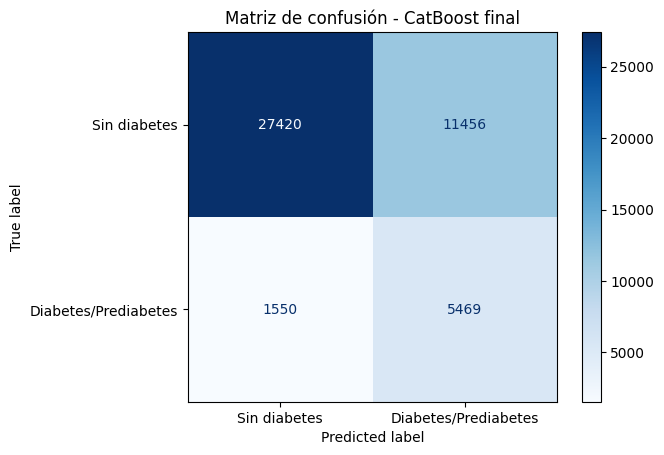

In [84]:
ConfusionMatrixDisplay.from_predictions(
    y_test_cb_final,
    y_pred_final_catboost,
    display_labels=[
        "Sin diabetes",
        "Diabetes/Prediabetes"
    ],
    cmap="Blues"
)

plt.title(
    "Matriz de confusión - CatBoost final"
)

plt.show()

In [85]:
# CatBoost - Escenario B (12 variables seleccionadas en el EDA)
# Mismo modelo y mismo threshold que el Escenario A, para comparar de forma justa.

# De las 12 seleccionadas, se identifican las categóricas (10). Las numéricas (BMI, PhysHlth) van tal cual.
cat_cols_catboost_B = [c for c in (binary_cols + ordinal_cols) if c in selected_features]

# CatBoost recibe las categóricas como texto, igual que en el Escenario A
X_train_cb_B = X_train_B.copy().reset_index(drop=True)
X_test_cb_B  = X_test_B.copy().reset_index(drop=True)
y_train_cb_B = y_train.copy().reset_index(drop=True)
y_test_cb_B  = y_test.copy().reset_index(drop=True)

for col in cat_cols_catboost_B:
    X_train_cb_B[col] = X_train_cb_B[col].astype(str)
    X_test_cb_B[col]  = X_test_cb_B[col].astype(str)

# Entrenamiento con los mismos hiperparámetros del modelo final
modelo_catboost_B = CatBoostClassifier(**PARAMETROS_CATBOOST_FINAL)
modelo_catboost_B.fit(X_train_cb_B, y_train_cb_B, cat_features=cat_cols_catboost_B)

# Predicción sobre el conjunto de prueba, aplicando el threshold final (0.49)
y_prob_cb_B = modelo_catboost_B.predict_proba(X_test_cb_B)[:, 1]
y_pred_cb_B = (y_prob_cb_B >= THRESHOLD_FINAL).astype(int)

# Métricas del Escenario B
resultados_cb_B = evaluar_modelo("CatBoost B - 12 variables", y_test_cb_B, y_pred_cb_B, y_prob_cb_B)
resultados_cb_B["F2 Clase 1"] = fbeta_score(y_test_cb_B, y_pred_cb_B, beta=2, pos_label=1, zero_division=0)

pd.DataFrame([resultados_cb_B]).set_index("Modelo").round(4)

,Accuracy,Balanced Accuracy,Precision Clase 0,Recall Clase 0,F1 Clase 0,Precision Clase 1,Recall Clase 1,F1 Clase 1,F1 Macro,F1 Weighted,ROC-AUC,PR-AUC Clase 1,F2 Clase 1
Modelo,,,,,,,,,,,,,
CatBoost B - 12 variables,0.7129,0.7368,0.9445,0.7023,0.8056,0.3187,0.7713,0.4511,0.6283,0.7514,0.8147,0.4396,0.6007


### **6.10 Selección del modelo final**

A partir del proceso de modelado, optimización y validación se selecciona **CatBoost** como modelo final del proyecto.

La selección se realizó utilizando exclusivamente resultados obtenidos mediante validación cruzada sobre el conjunto de entrenamiento y bajo un criterio orientado a priorizar el Recall de la clase Diabetes/Prediabetes.

CatBoost superó a la Regresión Logística V3 en las principales métricas asociadas con este objetivo, incluyendo Recall de la clase positiva, F2-score, Balanced Accuracy, ROC-AUC y PR-AUC, manteniendo simultáneamente un Recall cercano al 70% para la clase Sin diabetes.

Posteriormente, la configuración seleccionada fue evaluada sobre el conjunto de prueba sin modificar sus hiperparámetros ni su threshold.

En el conjunto de prueba, CatBoost obtuvo:

- Accuracy: 71.52%.
- Balanced Accuracy: 75.26%.
- Recall clase Sin diabetes: 70.08%.
- Recall clase Diabetes/Prediabetes: 80.45%.
- Precision clase Diabetes/Prediabetes: 30.33%.
- F1 clase Diabetes/Prediabetes: 44.05%.
- F2 clase Diabetes/Prediabetes: 60.46%.
- ROC-AUC: 82.74%.
- PR-AUC clase Diabetes/Prediabetes: 42.39%.

De las 7,069 observaciones positivas presentes en el conjunto de prueba, el modelo identificó correctamente 5,687 y dejó sin detectar 1,382.

El modelo final favorece deliberadamente la sensibilidad de la clase positiva. Como consecuencia, genera una cantidad considerable de falsos positivos y presenta una Precision más limitada para dicha clase.

Este comportamiento es coherente con el objetivo definido para el modelo, donde se considera más relevante reducir la cantidad de perfiles positivos no identificados que maximizar la Accuracy global.

El modelo debe interpretarse como una herramienta académica de clasificación e identificación preliminar de perfiles asociados con diabetes/prediabetes. Su resultado no constituye un diagnóstico médico.

## **7. Construcción del pipeline final y preparación para despliegue**

Una vez seleccionado y evaluado CatBoost como modelo final, se construye el pipeline de inferencia que permitirá utilizar el modelo de manera reproducible fuera del proceso de entrenamiento.

El pipeline integra las operaciones necesarias desde la recepción de una observación hasta la generación de la clasificación final:

1. recepción de las 21 variables predictoras;
2. validación de los valores de entrada;
3. organización de las variables en el mismo orden utilizado durante el entrenamiento;
4. transformación de las variables categóricas a la representación utilizada por CatBoost;
5. generación del score correspondiente a la clase Diabetes/Prediabetes;
6. aplicación del threshold final de 0.49;
7. generación de la clasificación final;
8. almacenamiento del modelo y sus metadatos para reutilización posterior.

El modelo final corresponde a **CatBoost**, con la siguiente configuración:

- `iterations = 400`;
- `depth = 6`;
- `learning_rate = 0.05`;
- `l2_leaf_reg = 3`;
- `auto_class_weights = "Balanced"`;
- `loss_function = "Logloss"`;
- threshold final = `0.49`.

Las variables binarias y ordinales son tratadas como variables categóricas por CatBoost, mientras que las variables numéricas se utilizan directamente.

El resultado generado corresponde a una clasificación producida por un modelo académico y no constituye un diagnóstico médico.

### **7.1 Definición del contrato de entrada del pipeline**

El pipeline final requiere exactamente las mismas 21 variables predictoras utilizadas durante el entrenamiento.

Para garantizar la reproducibilidad, se conserva explícitamente el nombre y orden de estas variables.

Este contrato de entrada permitirá posteriormente conectar el pipeline con cualquier aplicación externa, incluyendo la interfaz interactiva desarrollada en Gradio.

In [86]:
FEATURES_APP = list(
    X_train_A.columns
)

FEATURES_APP

['HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

### **7.2 Esquema de variables para la aplicación**

Las variables se agrupan según su naturaleza con el objetivo de facilitar posteriormente la construcción de los componentes de la interfaz.

Las variables binarias podrán representarse mediante controles de selección Sí/No, las variables ordinales mediante listas desplegables y las variables numéricas mediante campos numéricos o controles deslizantes.

In [87]:
INPUT_SCHEMA = {
    "binarias": binary_cols,
    "ordinales": ordinal_cols,
    "numericas": numeric_cols
}

INPUT_SCHEMA

{'binarias': ['HighBP',
  'HighChol',
  'CholCheck',
  'Smoker',
  'Stroke',
  'HeartDiseaseorAttack',
  'PhysActivity',
  'Fruits',
  'Veggies',
  'HvyAlcoholConsump',
  'AnyHealthcare',
  'NoDocbcCost',
  'DiffWalk',
  'Sex'],
 'ordinales': ['GenHlth', 'Age', 'Education', 'Income'],
 'numericas': ['BMI', 'MentHlth', 'PhysHlth']}

### **7.3 Definición de valores permitidos**

Para evitar que la aplicación envíe valores incompatibles con la estructura utilizada durante el entrenamiento, se identifican los valores permitidos para cada tipo de variable.

Las variables binarias deben tomar únicamente los valores 0 o 1.

Para las variables ordinales se almacenan las categorías observadas en los datos y para las variables numéricas se registran sus rangos observados.

Esta información será utilizada posteriormente para validar las entradas recibidas desde la interfaz.

In [88]:
valores_ordinales = {
    variable: sorted(
        df[variable]
        .dropna()
        .unique()
        .tolist()
    )
    for variable in ordinal_cols
}

rangos_numericos = {
    variable: {
        "min": float(df[variable].min()),
        "max": float(df[variable].max())
    }
    for variable in numeric_cols
}

print("VARIABLES ORDINALES")
display(valores_ordinales)

print("\nRANGOS NUMÉRICOS")
display(rangos_numericos)

VARIABLES ORDINALES


{'GenHlth': [1, 2, 3, 4, 5],
 'Age': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 'Education': [1, 2, 3, 4, 5, 6],
 'Income': [1, 2, 3, 4, 5, 6, 7, 8]}


RANGOS NUMÉRICOS


{'BMI': {'min': 12.0, 'max': 98.0},
 'MentHlth': {'min': 0.0, 'max': 30.0},
 'PhysHlth': {'min': 0.0, 'max': 30.0}}

### **7.4 Validación y preparación de entradas**

Antes de realizar una predicción, los valores ingresados por el usuario deben ser verificados.

La función de preparación comprueba:

- que estén presentes las 21 variables requeridas;
- que las variables binarias contengan únicamente 0 o 1;
- que las variables ordinales correspondan a categorías válidas;
- que las variables numéricas se encuentren dentro de los rangos observados en los datos.

Posteriormente se construye una observación en formato `DataFrame`, manteniendo exactamente el orden de variables utilizado durante el entrenamiento.

Finalmente, las variables binarias y ordinales son convertidas a tipo texto, reproduciendo exactamente la representación categórica utilizada para entrenar CatBoost.

In [89]:
def preparar_entrada(datos_usuario):

    # --------------------------------
    # 1. Verificar variables faltantes
    # --------------------------------

    faltantes = [
        variable
        for variable in FEATURES_APP
        if variable not in datos_usuario
    ]

    if faltantes:

        raise ValueError(
            f"Faltan variables requeridas: "
            f"{faltantes}"
        )


    # --------------------------------
    # 2. Validar variables binarias
    # --------------------------------

    for variable in binary_cols:

        valor = datos_usuario[
            variable
        ]

        if valor not in [0, 1]:

            raise ValueError(
                f"{variable} debe tomar "
                "únicamente los valores "
                "0 o 1."
            )


    # --------------------------------
    # 3. Validar variables ordinales
    # --------------------------------

    for variable in ordinal_cols:

        valor = datos_usuario[
            variable
        ]

        if valor not in valores_ordinales[
            variable
        ]:

            raise ValueError(
                f"Valor inválido para "
                f"{variable}. "
                f"Valores permitidos: "
                f"{valores_ordinales[variable]}"
            )


    # --------------------------------
    # 4. Validar variables numéricas
    # --------------------------------

    for variable in numeric_cols:

        valor = datos_usuario[
            variable
        ]

        minimo = rangos_numericos[
            variable
        ]["min"]

        maximo = rangos_numericos[
            variable
        ]["max"]

        if not minimo <= valor <= maximo:

            raise ValueError(
                f"{variable} debe encontrarse "
                f"entre {minimo} y {maximo}."
            )


    # --------------------------------
    # 5. Crear DataFrame
    # --------------------------------

    entrada = pd.DataFrame([
        {
            variable:
                datos_usuario[
                    variable
                ]

            for variable
            in FEATURES_APP
        }
    ])


    # --------------------------------
    # 6. Convertir variables
    # categóricas como en entrenamiento
    # --------------------------------

    for variable in cat_cols_catboost:

        entrada[variable] = (
            entrada[variable]
            .astype(str)
        )


    return entrada

### **7.5 Función de inferencia**

Se implementa una función encargada de conectar las entradas proporcionadas por el usuario con el modelo final CatBoost.

La función realiza los siguientes pasos:

1. valida las variables recibidas;
2. organiza las variables en el orden utilizado durante el entrenamiento;
3. convierte las variables categóricas a la representación utilizada por CatBoost;
4. obtiene el score generado por el modelo para la clase Diabetes/Prediabetes;
5. compara dicho score con el threshold final de 0.49;
6. devuelve la clasificación y el score generado.

El valor obtenido mediante `predict_proba()` se presenta como **score del modelo** y no debe interpretarse como una probabilidad clínica individual de desarrollar diabetes.

In [91]:
THRESHOLD_FINAL = THRESHOLD_CATBOOST

print("Threshold final del pipeline:", THRESHOLD_FINAL)

Threshold final del pipeline: 0.51


In [92]:
def predecir_perfil(datos_usuario):

    entrada = preparar_entrada(
        datos_usuario
    )

    score = float(
        modelo_final_catboost
        .predict_proba(
            entrada
        )[0, 1]
    )

    prediccion = int(
        score >= THRESHOLD_FINAL
    )

    if prediccion == 1:

        clasificacion = (
            "Diabetes/Prediabetes"
        )

    else:

        clasificacion = (
            "Sin diabetes"
        )

    return {

        "score_modelo":
            round(
                score,
                4
            ),

        "score_porcentaje":
            round(
                score * 100,
                2
            ),

        "prediccion":
            prediccion,

        "clasificacion":
            clasificacion,

        "threshold":
            THRESHOLD_FINAL
    }

### **7.6 Prueba de integración**

Antes de conectar el modelo con una aplicación externa, se realiza una prueba utilizando una observación real del conjunto de prueba.

El objetivo de esta prueba es verificar que:

- las 21 variables sean recibidas correctamente;
- la validación de las entradas funcione;
- Catboost pueda procesar una observación individual;
- la función de inferencia produzca una salida estructurada.

In [93]:
ejemplo_usuario = (
    X_test_A
    .iloc[0]
    .to_dict()
)

ejemplo_usuario

{'HighBP': 0,
 'HighChol': 0,
 'CholCheck': 1,
 'BMI': 27,
 'Smoker': 0,
 'Stroke': 0,
 'HeartDiseaseorAttack': 1,
 'PhysActivity': 1,
 'Fruits': 1,
 'Veggies': 1,
 'HvyAlcoholConsump': 0,
 'AnyHealthcare': 1,
 'NoDocbcCost': 0,
 'GenHlth': 3,
 'MentHlth': 0,
 'PhysHlth': 0,
 'DiffWalk': 0,
 'Sex': 1,
 'Age': 11,
 'Education': 5,
 'Income': 8}

In [94]:
resultado_ejemplo = predecir_perfil(
    ejemplo_usuario
)

resultado_ejemplo

{'score_modelo': 0.6195,
 'score_porcentaje': 61.95,
 'prediccion': 1,
 'clasificacion': 'Diabetes/Prediabetes',
 'threshold': 0.51}

### **7.7 Verificación de consistencia de la inferencia**

Se verifica que la clasificación devuelta por la función sea consistente con la aplicación manual del umbral seleccionado sobre el score generado por el modelo.

In [95]:
entrada_prueba = preparar_entrada(
    ejemplo_usuario
)

score_directo = float(
    modelo_final_catboost
    .predict_proba(
        entrada_prueba
    )[0, 1]
)

prediccion_esperada = int(
    score_directo >= THRESHOLD_FINAL
)

print(
    "Score directo:",
    round(
        score_directo,
        6
    )
)

print(
    "Predicción función:",
    resultado_ejemplo[
        "prediccion"
    ]
)

print(
    "Predicción esperada:",
    prediccion_esperada
)

print(
    "¿Predicción consistente?:",
    resultado_ejemplo[
        "prediccion"
    ]
    == prediccion_esperada
)

Score directo: 0.619458
Predicción función: 1
Predicción esperada: 1
¿Predicción consistente?: True


### **7.8 Persistencia del modelo**

Para permitir que la futura aplicación cargue el modelo sin necesidad de ejecutar nuevamente el notebook completo, se almacena CatBoost junto con la información necesaria para reproducir el proceso de inferencia.

Además del modelo se almacenan:

- el threshold final;
- las variables requeridas;
- las variables tratadas como categóricas;
- la clasificación de las variables según su naturaleza;
- las categorías ordinales válidas;
- los rangos permitidos de las variables numéricas;
- el significado de las clases;
- los hiperparámetros del modelo;
- información sobre la versión del artefacto.

De esta manera se genera un único paquete que podrá ser utilizado posteriormente desde la aplicación desarrollada en Gradio.

In [96]:
import joblib
import os

In [97]:
paquete_modelo = {

    # =================================
    # Modelo final
    # =================================

    "modelo":
        modelo_final_catboost,


    # =================================
    # Threshold final
    # =================================

    "threshold":
        THRESHOLD_FINAL,


    # =================================
    # Variables requeridas
    # =================================

    "features":
        FEATURES_APP,


    # =================================
    # Tipos de variables
    # =================================

    "binary_cols":
        binary_cols,

    "ordinal_cols":
        ordinal_cols,

    "numeric_cols":
        numeric_cols,


    # Variables tratadas como
    # categóricas por CatBoost

    "cat_cols":
        cat_cols_catboost,


    # =================================
    # Valores permitidos
    # =================================

    "valores_ordinales":
        valores_ordinales,

    "rangos_numericos":
        rangos_numericos,


    # =================================
    # Interpretación de clases
    # =================================

    "target_mapping": {
        0: "Sin diabetes",
        1: "Diabetes/Prediabetes"
    },


    # =================================
    # Configuración del modelo
    # =================================

    "model_type":
        "CatBoostClassifier",

    "model_parameters":
        PARAMETROS_CATBOOST_FINAL,


    # =================================
    # Información del score
    # =================================

    "score_description":
        (
            "Score generado por CatBoost "
            "para la clase "
            "Diabetes/Prediabetes. "
            "No representa un diagnóstico "
            "ni una probabilidad clínica."
        ),


    # =================================
    # Versión
    # =================================

    "version":
        "CatBoost_1.0"
}

In [98]:
os.makedirs(
    "models",
    exist_ok=True
)

In [99]:
os.makedirs(
    "models",
    exist_ok=True
)

MODEL_PATH = (
    "models/"
    "modelo_diabetes_catboost_final.joblib"
)

joblib.dump(
    paquete_modelo,
    MODEL_PATH
)

print(
    "Modelo guardado en:",
    MODEL_PATH
)

Modelo guardado en: models/modelo_diabetes_catboost_final.joblib


### **7.9 Carga y verificación del artefacto persistido**

Después de almacenar el pipeline final, el artefacto generado se carga nuevamente desde el archivo `.joblib`.

El objetivo es verificar que el archivo contiene el modelo CatBoost, el threshold y todos los metadatos necesarios para reproducir posteriormente el proceso de inferencia sin ejecutar nuevamente el entrenamiento.

In [100]:
paquete_cargado = joblib.load(
    MODEL_PATH
)

paquete_cargado.keys()

dict_keys(['modelo', 'threshold', 'features', 'binary_cols', 'ordinal_cols', 'numeric_cols', 'cat_cols', 'valores_ordinales', 'rangos_numericos', 'target_mapping', 'model_type', 'model_parameters', 'score_description', 'version'])

In [101]:
claves_esperadas = {
    "modelo",
    "threshold",
    "features",
    "binary_cols",
    "ordinal_cols",
    "numeric_cols",
    "cat_cols",
    "valores_ordinales",
    "rangos_numericos",
    "target_mapping",
    "model_type",
    "model_parameters",
    "score_description",
    "version"
}

print(
    "¿Artefacto completo?:",
    claves_esperadas.issubset(
        paquete_cargado.keys()
    )
)

print(
    "Modelo:",
    paquete_cargado[
        "model_type"
    ]
)

print(
    "Versión:",
    paquete_cargado[
        "version"
    ]
)

print(
    "Threshold:",
    paquete_cargado[
        "threshold"
    ]
)

¿Artefacto completo?: True
Modelo: CatBoostClassifier
Versión: CatBoost_1.0
Threshold: 0.51


### **7.10 Prueba end-to-end del pipeline persistido**

Finalmente se verifica que el modelo cargado desde el archivo persistido reproduzca exactamente el comportamiento del modelo original.

La misma observación es procesada por ambos modelos y se comparan:

- el score generado;
- la clasificación resultante;
- el threshold utilizado.

Esta prueba permite comprobar que el artefacto persistido puede ser utilizado posteriormente por una aplicación externa sin modificar el comportamiento del pipeline.

In [102]:
modelo_cargado = (
    paquete_cargado[
        "modelo"
    ]
)

threshold_cargado = float(
    paquete_cargado[
        "threshold"
    ]
)


entrada_prueba = preparar_entrada(
    ejemplo_usuario
)


# =====================================
# Modelo original
# =====================================

score_original = float(
    modelo_final_catboost
    .predict_proba(
        entrada_prueba
    )[0, 1]
)

pred_original = int(
    score_original
    >= THRESHOLD_FINAL
)


# =====================================
# Modelo cargado
# =====================================

score_cargado = float(
    modelo_cargado
    .predict_proba(
        entrada_prueba
    )[0, 1]
)

pred_cargada = int(
    score_cargado
    >= threshold_cargado
)

In [103]:
print(
    "Score modelo original:",
    round(
        score_original,
        6
    )
)

print(
    "Score modelo cargado:",
    round(
        score_cargado,
        6
    )
)

print(
    "\n¿Scores idénticos?:",
    np.isclose(
        score_original,
        score_cargado
    )
)

print(
    "¿Threshold idéntico?:",
    np.isclose(
        threshold_cargado,
        THRESHOLD_FINAL
    )
)

print(
    "¿Predicción idéntica?:",
    pred_original
    == pred_cargada
)

print(
    "\nPredicción final:",
    paquete_cargado[
        "target_mapping"
    ][
        pred_cargada
    ]
)

Score modelo original: 0.619458
Score modelo cargado: 0.619458

¿Scores idénticos?: True
¿Threshold idéntico?: True
¿Predicción idéntica?: True

Predicción final: Diabetes/Prediabetes
